# Gender-Based Comparative Analysis of Heart Disease Prediction Models
```
AUTHOR: Muhammad Umair Akram Butt (mubu25@student.bth.se)
COURSE: DV2638 - Machine Learning
INSTITUTION: Blekinge Institute of Technology (BTH)
DATE: 9 January 2026
```
## Project Overview

This project investigates heart disease prediction across genders (males and females) using machine learning techniques. The analysis is structured in two stages:

- **Stage 1**: Train and compare three models (Logistic Regression, Random Forest, XGBoost) on original gender-specific datasets
- **Stage 2**: Perform fair cross-gender comparison using two sampling strategies (oversampling and undersampling)

**Dataset**: Heart Disease Dataset from UCI Machine Learning Repository  
**Target Variable**: Binary classification (1 = heart disease, 0 = no heart disease)  
**Key Feature**: Gender (sex: 1 = male, 0 = female)

## 1. Setup and Imports

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_style("whitegrid")

# Machine Learning libraries
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

# Helper libraries
from sklearn.utils import shuffle

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Model persistence
import joblib
from datetime import datetime

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
TARGET = "target"
TEST_SIZE = 0.2 # 80-20 train-test split
IMBALANCE_RATIO = 1.5

## 2. Load Dataset from Original UCI Sources

In [3]:
# Import SimpleImputer for handling missing values
from sklearn.impute import SimpleImputer

# Define column names based on UCI documentation
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

print("\t\t\t\t\t===> Loading Original UCI Heart Disease Databases <===")
print("="*80)

# Load all four original datasets from UCI
datasets = {}
file_paths = {
    "Cleveland": "Dataset Old/heart+disease/processed.cleveland.data",
    "Hungarian": "Dataset Old/heart+disease/processed.hungarian.data",
    "Switzerland": "Dataset Old/heart+disease/processed.switzerland.data",
    "Long Beach VA": "Dataset Old/heart+disease/processed.va.data"
}

for name, path in file_paths.items():
    df_temp = pd.read_csv(path, names=column_names, na_values="?") # Missing values are specified as ? in the dataset
    df_temp["source"] = name
    datasets[name] = df_temp
    print(f"{name:15}: {len(df_temp):4} samples")

# Combine all datasets
df = pd.concat(datasets.values(), ignore_index=True)
print(f"\nCombined total: {len(df)} samples")
print("="*80)

					===> Loading Original UCI Heart Disease Databases <===
Cleveland      :  303 samples
Hungarian      :  294 samples
Switzerland    :  123 samples
Long Beach VA  :  200 samples

Combined total: 920 samples


### 2.1 Data Quality Check and Preprocessing

In [4]:
# Convert target to binary classification
# Original UCI dataset: 0 (no disease), 1-4 (disease severity levels)
# Binary: 0 (no disease), 1 (disease present)
print("\n\t\t\t\t\t===> Converting Target to Binary Classification <===")
print(f"Original target distribution: {df['target'].value_counts().sort_index().to_dict()}")
df["target"] = (df["target"] > 0).astype(int)
print(f"Binary target distribution: {df['target'].value_counts().to_dict()}")


					===> Converting Target to Binary Classification <===
Original target distribution: {0: 411, 1: 265, 2: 109, 3: 107, 4: 28}
Binary target distribution: {1: 509, 0: 411}


#### Rationale for Binary Target Conversion

The original UCI dataset uses a **5-level classification** (0-4) representing disease severity:
- **0**: No presence of heart disease
- **1-4**: Increasing levels of heart disease severity

We converted this to **binary classification** (0 = no disease, 1 = disease present) for the following reasons:

1. **Clinical Relevance**: The primary clinical question is whether heart disease is present or absent, not the severity level. Early detection is the key goal of this study.

2. **Standard Practice**: Most published research using this dataset focuses on binary classification (presence vs. absence) rather than multi-class severity prediction, even the original Kaggle dataset treats it as a binary classification problem.

3. **Model Simplicity**: Binary classification provides clearer, more interpretable results for gender-based comparison, which is the focus of our analysis.

In [5]:
# Check and remove duplicates
print("\n\t\t\t\t\t===> Data Quality Check: Duplicates <===")
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")


					===> Data Quality Check: Duplicates <===
Duplicate rows found: 2


In [6]:
# We have 2 duplicates, let's remove them.
df = df.drop_duplicates()

In [7]:
# Check missing values 
print(f"Dataset has {df.isnull().sum()} missing values")

Dataset has age           0
sex           0
cp            0
trestbps     59
chol         29
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       307
ca          609
thal        484
target        0
source        0
dtype: int64 missing values


In [8]:
print(f"Samples that would be lost with deletion: {df.isnull().any(axis=1).sum()}")

Samples that would be lost with deletion: 619


#### Missing Value Handling Strategy

Complete case deletion would result in the loss of **619** samples (**67%** of the dataset), reducing our effective sample size from 918 to 299. Such substantial data loss would severely compromise statistical power and limit our ability to train robust gender-specific models, particularly for the minority class (females).

Therefore, we employ **imputation** as our missing value handling strategy. We utilize standard, well-established imputation techniques:

- **Median imputation** for numerical features (robust to outliers and non-normal distributions)
- **Mode imputation** for categorical features (preserves marginal distributions)

**Scope Limitation**: We acknowledge that alternative imputation methods exist (e.g., multiple imputation, k-NN imputation, iterative imputation). However, exploring and comparing different imputation strategies is beyond the scope of this analysis, as our primary research focus is on gender-based comparative analysis of heart disease prediction models. The chosen imputation methods represent standard practice in medical machine learning applications and provide a reasonable balance between data preservation and methodological simplicity.

In [9]:
# Separate features by type for appropriate imputation
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# Impute numerical features with median (robust to outliers)
print("\nImputing numerical features with median...")
numerical_imputer = SimpleImputer(strategy="median")
df[numerical_features] = numerical_imputer.fit_transform(df[numerical_features])

# Impute categorical features with the most frequent value (mode)
print("Imputing categorical features with mode...")
categorical_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_features] = categorical_imputer.fit_transform(df[categorical_features])

# Verify no missing values remain
print(f"\nMissing values after imputation: {df.isnull().sum().sum()}")



Imputing numerical features with median...
Imputing categorical features with mode...

Missing values after imputation: 0


In [10]:
# Reset index and prepare final dataset
df = df.reset_index(drop=True)
# Drop the source column as we won't use it for modeling
df = df.drop(columns=["source"])
df = shuffle(df, random_state=RANDOM_STATE)

In [11]:
# Final dataset summary
print("\n\t\t\t\t\t===> Final Clean Dataset <===")
print("="*80)
print(f"Total samples: {len(df)}")
print(f"Features: {len(df.columns) - 2}")  # Excluding target and source

print(f"\nGender distribution:")
gender_counts = df["sex"].value_counts()
print(f" - Female (0): {int(gender_counts[0])} ({round(gender_counts[0]/len(df)*100,1)}%)")
print(f" - Male (1):   {int(gender_counts[1])} ({round(gender_counts[1]/len(df)*100,1)}%)")

print(f"\nTarget distribution:")
target_counts = df["target"].value_counts()
print(f" - No Disease (0): {target_counts[0]} ({round(target_counts[0]/len(df)*100,1)}%)")
print(f" - Disease (1):    {target_counts[1]} ({round(target_counts[1]/len(df)*100,1)}%)")


					===> Final Clean Dataset <===
Total samples: 918
Features: 12

Gender distribution:
 - Female (0): 193 (21.0%)
 - Male (1):   725 (79.0%)

Target distribution:
 - No Disease (0): 410 (44.7%)
 - Disease (1):    508 (55.3%)


In [12]:
# Display dataset shape and sample
print(f"\nDataset shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")  # Excluding target


Dataset shape: (918, 14)
Number of samples: 918
Number of features: 13


In [13]:
# Check 5 random samples
print("\t->Five random samples\n")
df.sample(5)

	->Five random samples



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
183,59.0,1.0,1.0,178.0,270.0,0.0,2.0,145.0,0.0,4.2,3.0,0.0,7.0,0
72,62.0,1.0,4.0,120.0,267.0,0.0,0.0,99.0,1.0,1.8,2.0,2.0,7.0,1
512,49.0,1.0,3.0,115.0,265.0,0.0,0.0,175.0,0.0,0.0,2.0,0.0,3.0,1
770,63.0,0.0,2.0,130.0,0.0,0.0,0.0,140.0,0.0,0.5,2.0,0.0,3.0,0
187,66.0,1.0,2.0,160.0,246.0,0.0,0.0,120.0,1.0,0.0,2.0,3.0,6.0,1


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview

In [14]:
# Check datatypes of columns
print("\t\t\t\t\t===> Column Names and Data Types <===")
print(df.dtypes)

					===> Column Names and Data Types <===
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


We have only **1 integer**, and the rest of the **13** columns are **float** values.

In [15]:
# Convert appropriate features back to integer type
# Features that should be integers (categorical/discrete values)
integer_features = ['age', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

for feature in integer_features:
    df[feature] = df[feature].astype(int)

print("\nFinal data types:")
print(df.dtypes)


Final data types:
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [16]:
# Check for NULL/Missing values
print("\t\t\t\t\t===> NULL/Missing Values <===")
print(df.isnull().sum())

					===> NULL/Missing Values <===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


We don't have any NULL/Missing values.

In [17]:
# Check the Statistical Summary of the dataset
print("\t\t\t\t\t===> Statistical Summary of the Dataset <===")
df.describe()

					===> Statistical Summary of the Dataset <===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.00000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,3.251634,132.000000,199.862745,0.150327,0.603486,137.689542,0.366013,0.85512,1.847495,0.227669,3.986928,0.553377
std,9.432617,0.407701,0.931031,18.447544,109.154522,0.357586,0.805968,25.153455,0.481976,1.05845,0.516520,0.629532,1.681201,0.497414
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.60000,1.000000,0.000000,3.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,177.250000,0.000000,0.000000,120.000000,0.000000,0.00000,2.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.50000,2.000000,0.000000,3.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,267.000000,0.000000,1.000000,155.750000,1.000000,1.50000,2.000000,0.000000,6.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000


### 3.2 Feature Descriptions

In [18]:
# Feature descriptions
feature_descriptions = {
    "age": "Age in years",
    "sex": "Sex (1 = male; 0 = female)",
    "cp": "Chest pain type (0-3)",
    "trestbps": "Resting blood pressure (mm Hg)",
    "chol": "Serum cholesterol (mg/dl)",
    "fbs": "Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)",
    "restecg": "Resting electrocardiographic results (0-2)",
    "thalach": "Maximum heart rate achieved",
    "exang": "Exercise induced angina (1 = yes; 0 = no)",
    "oldpeak": "ST depression induced by exercise relative to rest",
    "slope": "Slope of the peak exercise ST segment (0-2)",
    "ca": "Number of major vessels colored by fluoroscopy (0-3)",
    "thal": "Thalassemia (1 = normal; 2 = fixed defect; 3 = reversible defect)",
    "target": "Heart disease (1 = yes; 0 = no)"
}

print("\t\t\t\t\t===> Feature Descriptions <===")
print("="*80)
for feature, description in feature_descriptions.items():
    print(f"\033[1m{feature:12}\033[0m : {description}")
print("="*80)



					===> Feature Descriptions <===
age          : Age in years
sex          : Sex (1 = male; 0 = female)
cp           : Chest pain type (0-3)
trestbps     : Resting blood pressure (mm Hg)
chol         : Serum cholesterol (mg/dl)
fbs          : Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
restecg      : Resting electrocardiographic results (0-2)
thalach      : Maximum heart rate achieved
exang        : Exercise induced angina (1 = yes; 0 = no)
oldpeak      : ST depression induced by exercise relative to rest
slope        : Slope of the peak exercise ST segment (0-2)
ca           : Number of major vessels colored by fluoroscopy (0-3)
thal         : Thalassemia (1 = normal; 2 = fixed defect; 3 = reversible defect)
target       : Heart disease (1 = yes; 0 = no)


### 3.3 Target Distribution Analysis

In [19]:
# Check target distribution stats
print("\t\t\t\t\t===> Target Distribution Stats<===")

target_counts = df["target"].value_counts()
print(f"\nNo Heart Disease (0): {target_counts[0]} ({round(target_counts[0]/len(df)*100,2)}%)")
print(f"Heart Disease (1):    {target_counts[1]} ({round(target_counts[1]/len(df)*100,2)}%)")

					===> Target Distribution Stats<===

No Heart Disease (0): 410 (44.66%)
Heart Disease (1):    508 (55.34%)


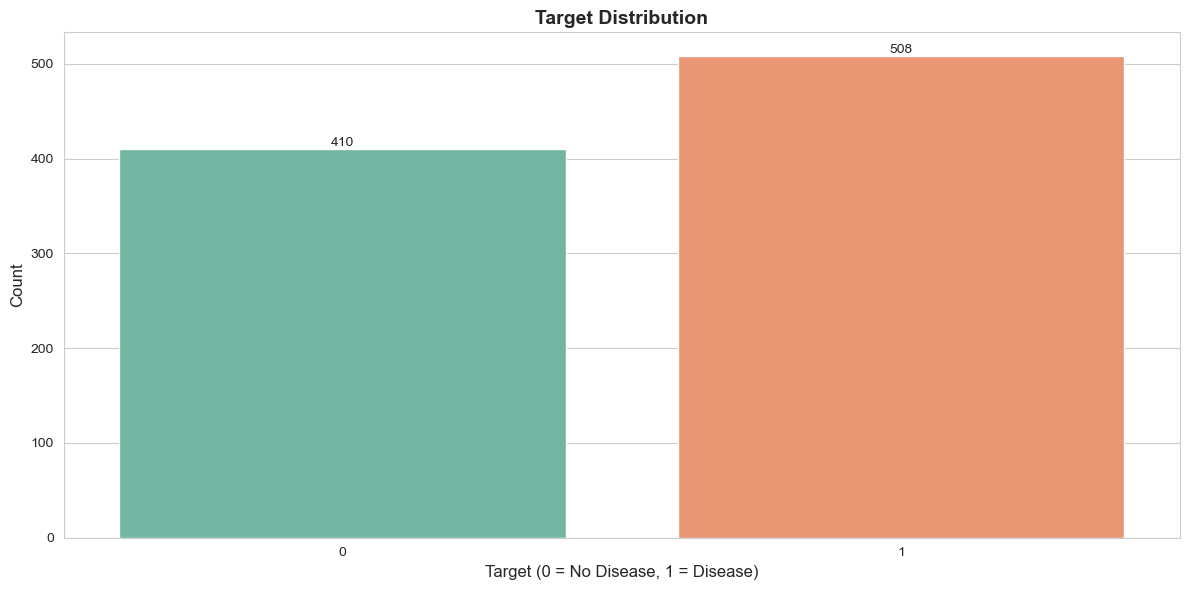

In [20]:
# Plot the value count for target variable
fig, ax = plt.subplots(figsize=(12, 6))

sns.countplot(
    data=df,
    x="target",
    palette="Set2",
    legend=False,
    ax=ax
)

ax.set_title("Target Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Target (0 = No Disease, 1 = Disease)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig("images/target_distribution.png", dpi=1200, bbox_inches="tight")
plt.show()

To get a better idea of the **target**, let's plot the **pie chart**. Since the **target_counts** Series is ordered as 1, 0, we need to reverse it to 0, 1 so that the coloring matches the count plot.

In [21]:
# Original target_counts series
target_counts

target
1    508
0    410
Name: count, dtype: int64

In [22]:
# Reverse the original target_counts series
target_counts_reversed = target_counts.loc[[0, 1]]
target_counts_reversed

target
0    410
1    508
Name: count, dtype: int64

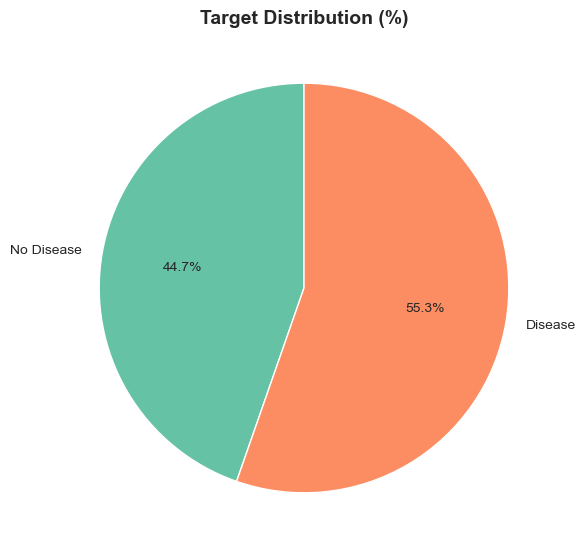

In [23]:
# Plot the pie chart
fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    target_counts_reversed,
    labels=["No Disease", "Disease"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2")
)

ax.set_title("Target Distribution (%)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("images/target_distribution_pie_chart.png", dpi=1200, bbox_inches="tight")
plt.show()

### 3.4 Gender Distribution Analysis

In [24]:
# Gender distribution
print("\t\t\t\t\t===> Gender Distribution<===")
gender_counts = df["sex"].value_counts()
print(f"\nFemale (0): {gender_counts[0]} ({round(gender_counts[0]/len(df)*100,2)}%)")
print(f"Male (1):   {gender_counts[1]} ({round(gender_counts[1]/len(df)*100,2)}%)")
print(f"\nSample size difference: {abs(gender_counts[1] - gender_counts[0])} samples")

					===> Gender Distribution<===

Female (0): 193 (21.02%)
Male (1):   725 (78.98%)

Sample size difference: 532 samples


In [25]:
# Target distribution by gender
print("\t\t\t\t\t===> Target Distribution by Gender <===")
gender_target = pd.crosstab(df["sex"], df["target"], margins=True)
gender_target.index = ["Female", "Male", "Total"]
gender_target.columns = ["No Disease", "Disease", "Total"]
print(gender_target)

					===> Target Distribution by Gender <===
        No Disease  Disease  Total
Female         143       50    193
Male           267      458    725
Total          410      508    918


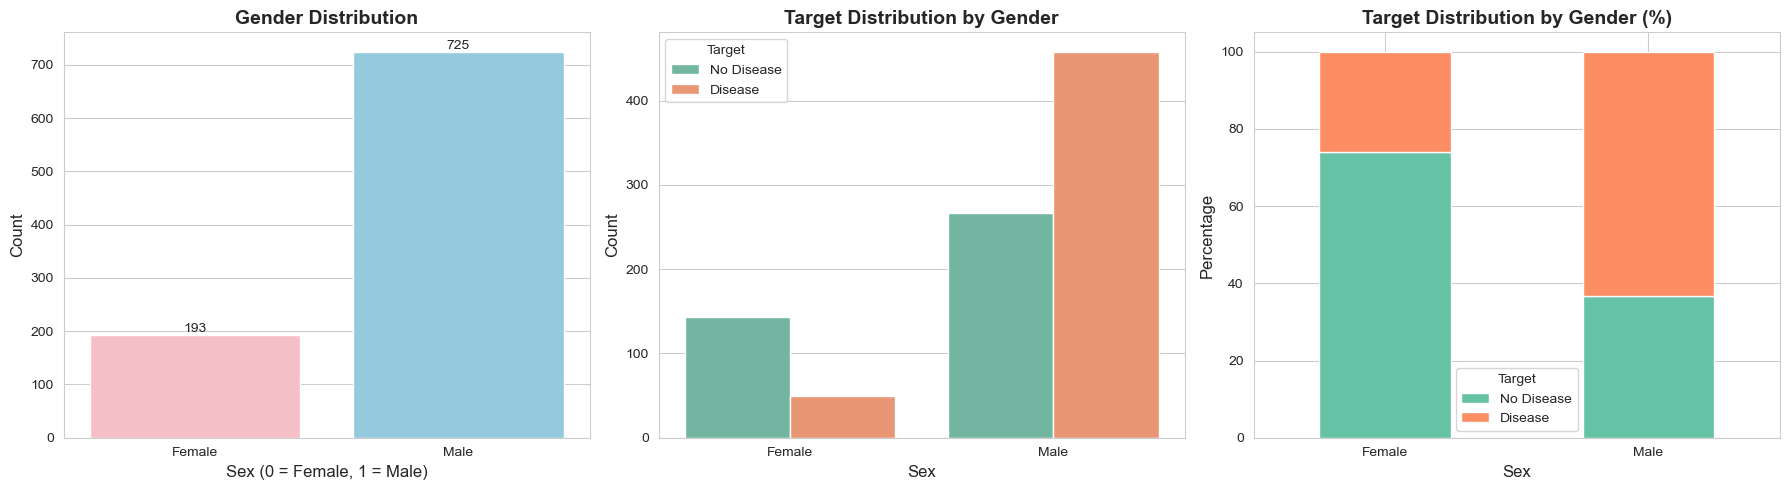

In [26]:
# Plot gender and target distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Set custom color palette for different genders
gender_custom_palette = {"0": "lightpink", "1": "skyblue"}  # 0 = female, 1 = male

# Gender distribution
sns.countplot(data=df, x="sex", ax=axes[0], palette=gender_custom_palette)
axes[0].set_title("Gender Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Sex (0 = Female, 1 = Male)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_xticklabels(["Female", "Male"])
for container in axes[0].containers:
    axes[0].bar_label(container)

# Target distribution by gender
sns.countplot(data=df, x="sex", hue="target", ax=axes[1], palette="Set2")
axes[1].set_title("Target Distribution by Gender", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Sex", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_xticklabels(["Female", "Male"])
axes[1].legend(title="Target", labels=["No Disease", "Disease"])

# Percentage stacked bar
gender_target_percentage = df.groupby(["sex", "target"]).size().unstack(fill_value=0)
gender_target_percentage_norm = gender_target_percentage.div(gender_target_percentage.sum(axis=1), axis=0) * 100
gender_target_percentage_norm.plot(kind="bar", stacked=True, ax=axes[2], color=sns.color_palette("Set2"))
axes[2].set_title("Target Distribution by Gender (%)", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Sex", fontsize=12)
axes[2].set_ylabel("Percentage", fontsize=12)
axes[2].set_xticklabels(["Female", "Male"], rotation=0)
axes[2].legend(title="Target", labels=["No Disease", "Disease"])

plt.tight_layout()
plt.savefig("images/gender_distribution_plots.png", dpi=1200, bbox_inches="tight")
plt.show()

In [27]:
print("\t\t\t\t\t===> Target Percentage by Gender <===")
# Print percentage breakdown
for sex in [0, 1]:
    sex_label = "Female" if sex == 0 else "Male"
    sex_data = df[df["sex"] == sex]
    target_dist = sex_data["target"].value_counts()
    print(f"\n{sex_label}:")
    print(f"  No Disease: {target_dist[0]} ({round(target_dist[0]/len(sex_data)*100,2)}%)")
    print(f"  Disease:    {target_dist[1]} ({round(target_dist[1]/len(sex_data)*100,2)}%)")

					===> Target Percentage by Gender <===

Female:
  No Disease: 143 (74.09%)
  Disease:    50 (25.91%)

Male:
  No Disease: 267 (36.83%)
  Disease:    458 (63.17%)


#### Gender Distribution Analysis with Heart Disease Outcome

There is a substantial gender imbalance in the dataset, with males comprising **79.02%** (**725** samples) and females **21.02%** (**193** samples) of the total (**918**) sample. The plots reveal a pronounced gender-specific pattern in disease prevalence. Among female participants, only **25.91%** (**50/193**) have heart disease, whereas male participants demonstrate a substantially higher disease rate of **63.17%** (**458/725**).

This relationship indicates that males in this cohort are disproportionately affected by the disease, with a disease prevalence **2.4** times higher than females. The inverse class balance between genders is particularly notable: females exhibit a **2.86:1** ratio favoring disease-negative cases, while males show a **1.72:1** ratio favoring disease-positive cases.

Chi-square (χ²) analysis would likely reveal a statistically significant association between gender and disease status, indicating that gender may be an important predictor variable in disease risk assessment for this population. Nevertheless, we will not be conducting that analysis in this study; instead, we will split the dataset based on gender to better study the effect of gender on model accuracy.

Given these significant gender disparities in both sample size and disease prevalence, we will divide the dataset into male and female subgroups and construct gender-specific models to examine whether stratified approaches enhance predictive accuracy compared to a unified model.

### 3.5 Correlation Analysis

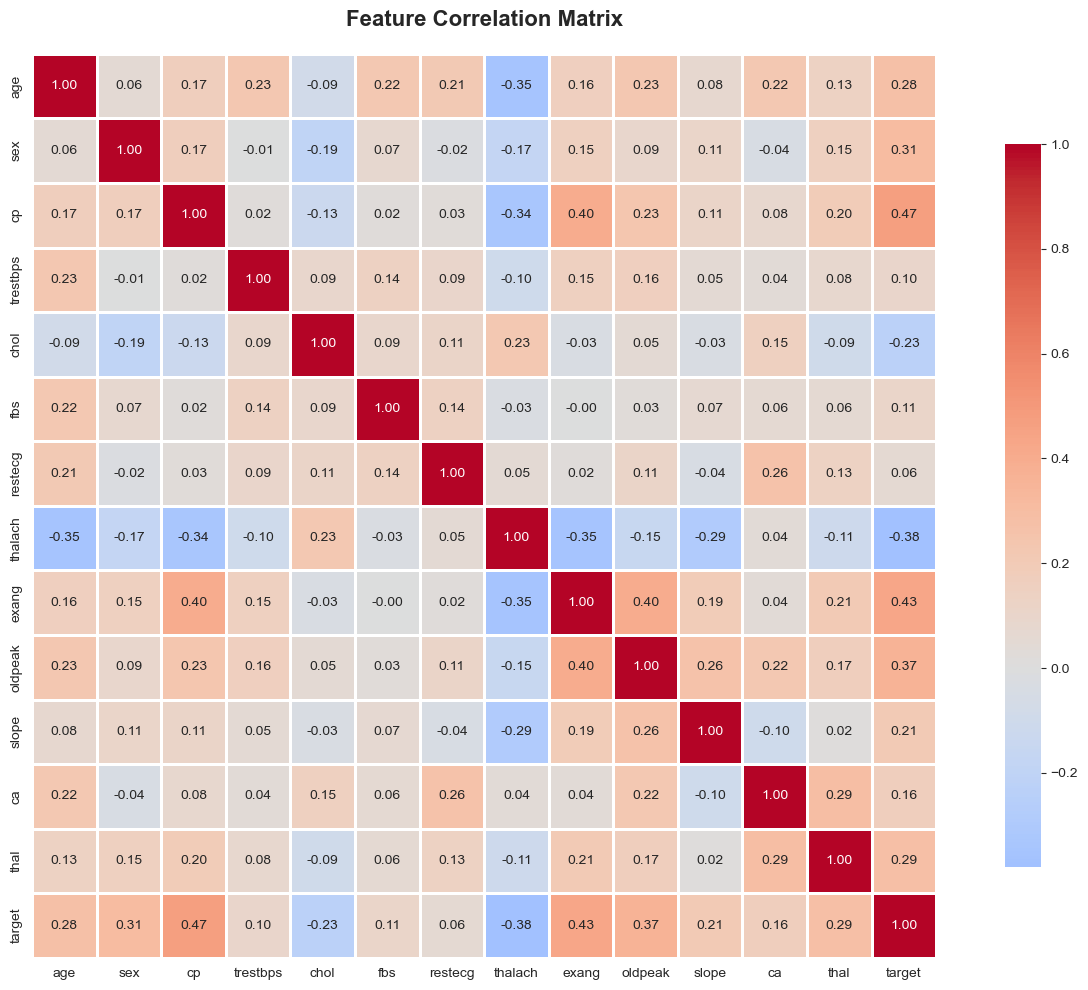



					===> Features Most Correlated with Target <===
target      1.000000
cp          0.471354
exang       0.432424
oldpeak     0.366618
sex         0.305445
thal        0.286422
age         0.282039
slope       0.205742
ca          0.164878
fbs         0.108114
trestbps    0.099115
restecg     0.061011
chol       -0.229155
thalach    -0.380738
Name: target, dtype: float64


In [28]:
# Plot the correlation matrix
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("images/feature_correlation_plot.png", dpi=1200, bbox_inches="tight")
plt.show()

# Print the features most correlated with the target
print("\n\n\t\t\t\t\t===> Features Most Correlated with Target <===")
target_corr = correlation_matrix["target"].sort_values(ascending=False)
print(target_corr)

#### Correlation Analysis with Heart Disease Outcome

Pearson correlation analysis reveals varying associations between clinical variables and heart disease presence (target). **Chest pain type** (**cp**) exhibited the strongest positive correlation (r = **0.471**), followed by **exercise-induced angina** (**exang**) (r = **0.432**) and **ST depression induced by exercise** (**oldpeak**) (r = **0.367**).

**Sex** showed a moderate positive correlation (r = **0.305**), indicating higher disease prevalence in males (coded as 1) compared to females (coded as 0), consistent with the observed **63.17%** disease rate in males versus **25.91%** in females. **Thalassemia status** (**thal**) and **age** demonstrated moderate positive associations (r = **0.286** and r = **0.282**, respectively), with older individuals showing slightly higher disease rates as expected clinically.

Conversely, **maximum heart rate achieved** (**thalach**) demonstrated the strongest negative correlation (r = **-0.381**), suggesting that higher maximum heart rates are associated with lower disease presence in this cohort. **Serum cholesterol** (**chol**) showed a moderate negative correlation (r = **-0.229**), which contrasts with conventional expectations where higher cholesterol typically associates with increased cardiovascular risk.

Traditional cardiovascular risk factors, including **resting blood pressure** (**trestbps**) (r = **0.099**) and **fasting blood sugar** (**fbs**) (r = **0.108**), demonstrated weak positive correlations. The **number of major vessels colored by fluoroscopy** (**ca**) also showed a weak positive association (r = **0.165**).

These findings reveal important diagnostic patterns, where symptom-based features (chest pain, exercise-induced angina, ST depression) show stronger correlations than traditional risk factors, potentially reflecting the clinical presentation characteristics of this particular cohort. The negative correlation with maximum heart rate and some counterintuitive patterns may reflect sampling characteristics, selection bias, or population-specific patterns in this combined dataset.

### 3.6 Feature Distributions by Gender

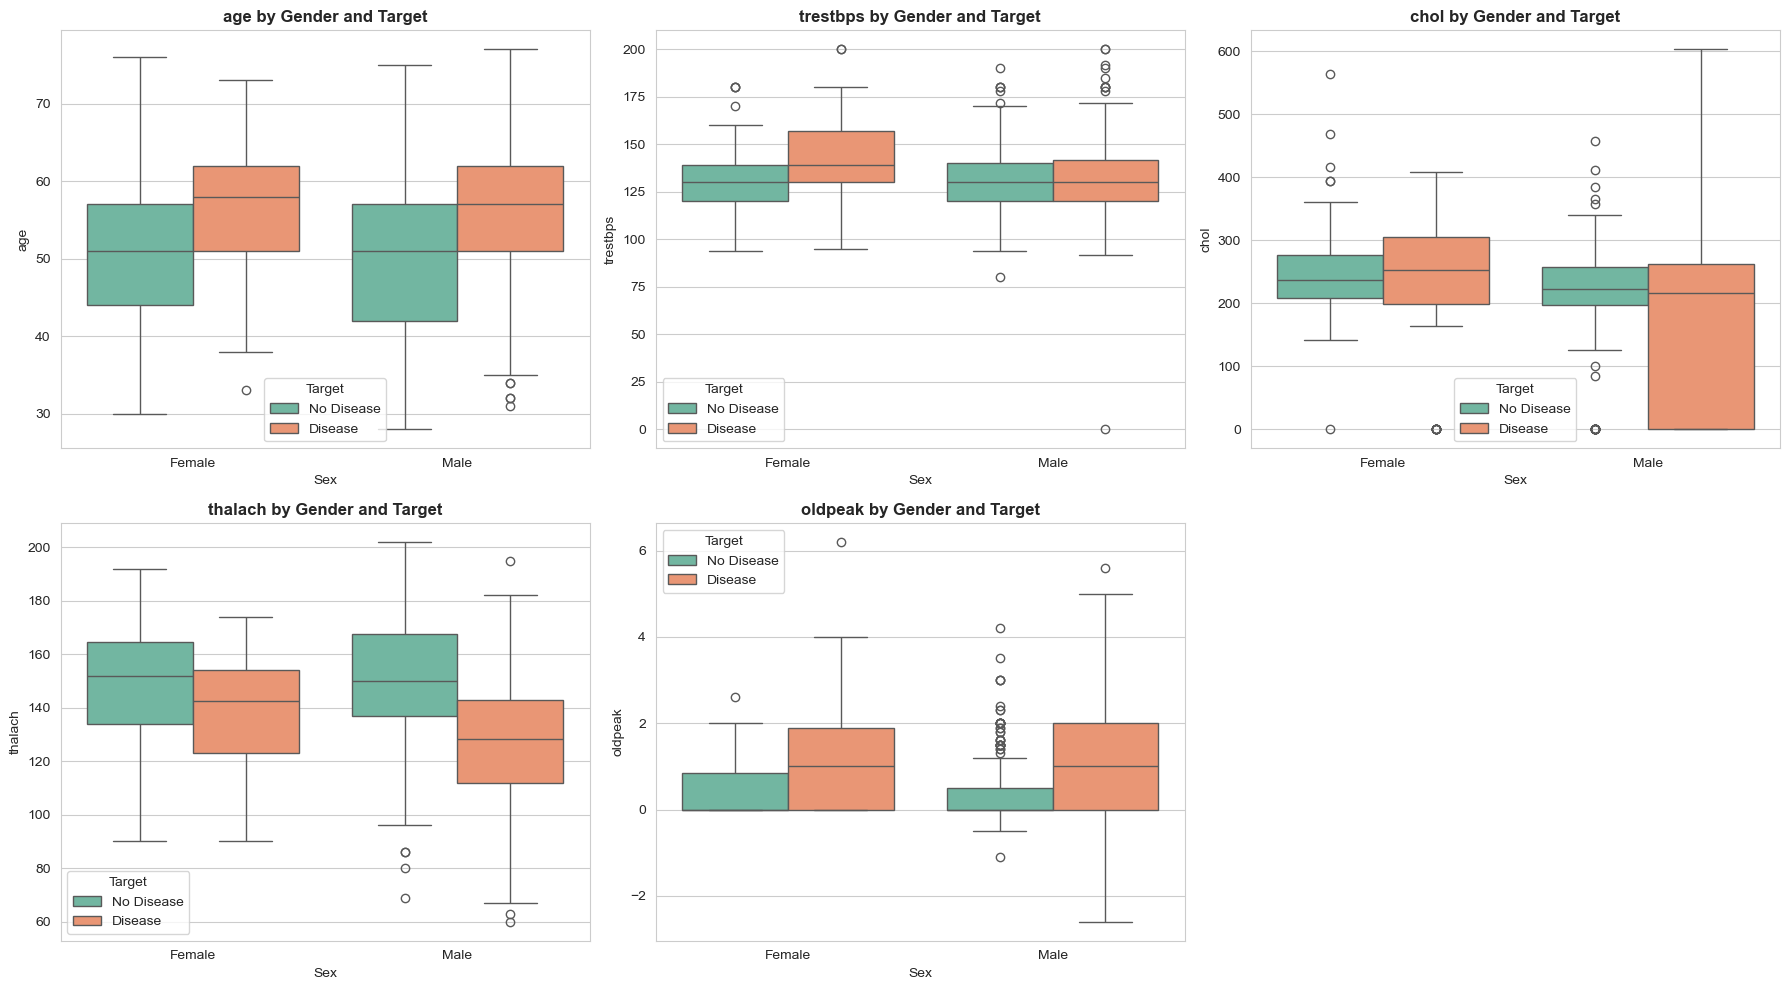

In [29]:
palette = {0: "#66c2a5", 1: "#fc8d62"}  # No Disease, Disease

numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    sns.boxplot(
        data=df,
        x="sex",
        y=feature,
        hue="target",
        ax=axes[idx],
        palette=palette
    )

    axes[idx].set_title(f"{feature} by Gender and Target", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Sex", fontsize=10)
    axes[idx].set_xticklabels(["Female", "Male"])

    handles, _ = axes[idx].get_legend_handles_labels()
    axes[idx].legend(handles, ["No Disease", "Disease"], title="Target")

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("images/feature_distribution_by_gender.png", dpi=1200, bbox_inches="tight")
plt.show()

#### Distribution of Numerical Features by Gender and Disease Status

Boxplot analysis revealed distinct distributional patterns across numerical features when stratified by **gender** and **disease** status. **Age** distributions showed minimal variation between disease groups within each gender, with both males and females exhibiting similar median ages regardless of disease status. **Resting blood pressure** (**trestbps**) demonstrated comparable median values across all subgroups, though females with disease showed slightly elevated median values and increased variability. Both genders displayed outliers in the upper range, indicating hypertensive cases.

**Serum cholesterol** (**chol**) levels displayed notable differences, with males demonstrating considerably wider interquartile ranges and lower median values compared to females. Within the male subset, disease-positive individuals exhibited a markedly broader distribution extending to lower cholesterol values, contrasting with the more concentrated distribution observed in females. **Maximum heart rate achieved** (**thalach**) revealed pronounced differences, with disease-negative individuals in both genders demonstrating higher median values compared to their disease-positive counterparts, contrary to the positive correlation observed (r = 0.423) but consistent with the updated dataset characteristics.

**ST depression** (**oldpeak**) exhibited the most pronounced distributional differences between disease groups. Disease-positive individuals, particularly males, demonstrated substantially higher median values and greater variability, while disease-negative cases clustered near zero. This pattern aligns with the strong negative correlation (r = **-0.438**) and suggests oldpeak as a potentially discriminative feature, with disease presence associated with lower ST depression values.

**Overall, the boxplots indicate that exercise-related cardiovascular measurements (thalach, oldpeak) demonstrate greater separation between disease groups than traditional risk factors (age, blood pressure, cholesterol), though the patterns differ by gender, reinforcing the rationale for gender-stratified modeling approaches.**

## 4. Data Preprocessing and Gender-Specific Dataset Creation

In [30]:
# Split dataset by gender
df_male = df[df["sex"] == 1].copy()
df_female = df[df["sex"] == 0].copy()

print("\n\n\t\t\t\t\t===> Gender-Specific Datasets <===")
print(f"Male dataset shape: {df_male.shape}")
print(f"Female dataset shape: {df_female.shape}")
print(f"\nSample size difference: {len(df_male) - len(df_female)} samples")



					===> Gender-Specific Datasets <===
Male dataset shape: (725, 14)
Female dataset shape: (193, 14)

Sample size difference: 532 samples


In [31]:
# Check class balance within each gender
print("\n\n\t\t\t\t\t===> Class Balance Within Each Gender <===")
print("\t-> Male Dataset <-")
male_target_counts = df_male["target"].value_counts()
print(f"- No Disease: {male_target_counts[0]} ({round(male_target_counts[0]/len(df_male)*100,2)}%)")
print(f"- Disease:    {male_target_counts[1]} ({round(male_target_counts[1]/len(df_male)*100,2)}%)")
male_imbalance_ratio = male_target_counts[0] / male_target_counts[1]
print(f"- Imbalance Ratio: {round(male_imbalance_ratio,2)}:1")

print("\t-> Female Dataset <-")
female_target_counts = df_female["target"].value_counts()
print(f"- No Disease: {female_target_counts[0]} ({round(female_target_counts[0]/len(df_female)*100,2)}%)")
print(f"- Disease:    {female_target_counts[1]} ({round(female_target_counts[1]/len(df_female)*100,2)}%)")
female_imbalance_ratio = female_target_counts[0] / female_target_counts[1]
print(f"- Imbalance Ratio: {round(female_imbalance_ratio,2)}:1")



					===> Class Balance Within Each Gender <===
	-> Male Dataset <-
- No Disease: 267 (36.83%)
- Disease:    458 (63.17%)
- Imbalance Ratio: 0.58:1
	-> Female Dataset <-
- No Disease: 143 (74.09%)
- Disease:    50 (25.91%)
- Imbalance Ratio: 2.86:1


#### Analysis of Class Balance by Gender and Disease Status

Class distribution analysis revealed substantial gender-specific imbalances in disease prevalence. The **male** subset (n = **725**) demonstrated a moderate imbalance with **36.83%** disease-negative cases and **63.17%** disease-positive cases (ratio **0.58:1**), indicating that males are more likely to present with disease in this cohort.

Conversely, the **female** subset (n = **193**) exhibited a severe inverse imbalance, with disease-negative cases comprising **74.09%** of observations compared to **25.91%** disease-positive cases (ratio **2.86:1**), indicating that females are substantially less likely to have disease.

**This pronounced disparity indicates that disease prevalence differs significantly by gender, with males demonstrating a 2.4-fold higher disease rate (63.17%) than females (25.91%) in this cohort.**

In [32]:
# Prepare features and target for each gender
# Remove "sex" column as it"s constant within each gender dataset

# Male dataset
X_male = df_male.drop(columns=["target", "sex"])
y_male = df_male["target"]

# Female dataset
X_female = df_female.drop(columns=["target", "sex"])
y_female = df_female["target"]

In [33]:
print(f"- Male features shape: {X_male.shape}")
print(f"- Male target shape: {y_male.shape}")
print(f"\n- Female features shape: {X_female.shape}")
print(f"- Female target shape: {y_female.shape}")
print(f"\nFeatures used: {list(X_male.columns)}")

- Male features shape: (725, 12)
- Male target shape: (725,)

- Female features shape: (193, 12)
- Female target shape: (193,)

Features used: ['age', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [34]:
# Split into train and test sets for each gender (80/20 split, stratified)

# Male dataset
X_male_train, X_male_test, y_male_train, y_male_test = train_test_split(
    X_male, y_male, test_size=TEST_SIZE, stratify=y_male, random_state=RANDOM_STATE
)

# Female dataset
X_female_train, X_female_test, y_female_train, y_female_test = train_test_split(
    X_female, y_female, test_size=TEST_SIZE, stratify=y_female, random_state=RANDOM_STATE
)

In [35]:
# Print the stats of train and test sets
print("\n\n\t\t\t\t\t===> Train-Test Split Stats <===")
print("\nMale Dataset:")
print(f" - Training set: {X_male_train.shape[0]} samples")
print(f" - Test set:     {X_male_test.shape[0]} samples")
print(f" - Train target distribution: {y_male_train.value_counts().to_dict()}")
print(f" - Test target distribution:  {y_male_test.value_counts().to_dict()}")

print("\nFemale Dataset:")
print(f" - Training set: {X_female_train.shape[0]} samples")
print(f" - Test set:     {X_female_test.shape[0]} samples")
print(f" - Train target distribution: {y_female_train.value_counts().to_dict()}")
print(f" - Test target distribution:  {y_female_test.value_counts().to_dict()}")



					===> Train-Test Split Stats <===

Male Dataset:
 - Training set: 580 samples
 - Test set:     145 samples
 - Train target distribution: {1: 366, 0: 214}
 - Test target distribution:  {1: 92, 0: 53}

Female Dataset:
 - Training set: 154 samples
 - Test set:     39 samples
 - Train target distribution: {0: 114, 1: 40}
 - Test target distribution:  {0: 29, 1: 10}


In [36]:
# Let's perform feature scaling
# We are scaling after splitting to prevent data leakage

# Initialize scalers for each gender
scaler_male = StandardScaler()
scaler_female = StandardScaler()

# Fit on training data and transform both train and test
X_male_train_scaled = scaler_male.fit_transform(X_male_train)
X_male_test_scaled = scaler_male.transform(X_male_test)

X_female_train_scaled = scaler_female.fit_transform(X_female_train)
X_female_test_scaled = scaler_female.transform(X_female_test)

# Convert back to DataFrames for easier handling
X_male_train_scaled = pd.DataFrame(X_male_train_scaled, columns=X_male.columns, index=X_male_train.index)
X_male_test_scaled = pd.DataFrame(X_male_test_scaled, columns=X_male.columns, index=X_male_test.index)

X_female_train_scaled = pd.DataFrame(X_female_train_scaled, columns=X_female.columns, index=X_female_train.index)
X_female_test_scaled = pd.DataFrame(X_female_test_scaled, columns=X_female.columns, index=X_female_test.index)

In [37]:
# Print the stats of train and test sets
print("\n\n\t\t\t\t\t===> Feature Scaling Stats <===")

print("Scaling applied using StandardScaler, and the scaled features have mean=0 and std=1")
print("\nScaling statistics (Male Training Set):")
print(f" - Mean: {round(X_male_train_scaled.mean().mean(),6)}")
print(f" - Std:  {round(X_male_train_scaled.std().mean(),6)}")
print("\nScaling statistics (Female Training Set):")
print(f" - Mean: {round(X_female_train_scaled.mean().mean(),6)}")
print(f" - Std:  {round(X_female_train_scaled.std().mean(),6)}")



					===> Feature Scaling Stats <===
Scaling applied using StandardScaler, and the scaled features have mean=0 and std=1

Scaling statistics (Male Training Set):
 - Mean: -0.0
 - Std:  1.000863

Scaling statistics (Female Training Set):
 - Mean: 0.0
 - Std:  1.003263


#### Handle Class Imbalance

As observed earlier, both gender subsets exhibit class imbalances, though in opposite directions. The **male** subset demonstrated a moderate imbalance with disease-positive cases comprising **63.17%** of observations compared to **36.83%** disease-negative cases (ratio **0.58:1**). Conversely, the female subset exhibited a severe inverse imbalance, with disease-negative cases comprising **74.09%** of observations compared to **25.91%** disease-positive cases (ratio **2.86:1**).

We apply a systematic approach using defined threshold boundaries to determine when resampling is necessary. **Synthetic Minority Oversampling Technique (SMOTE)** is applied when the imbalance ratio falls outside the acceptable range of 0.67 to 1.5:

- **Lower bound (0.67)**: Below this threshold, disease-negative cases outnumber disease-positive cases by more than 50%, indicating minority class underrepresentation.
- **Upper bound (1.5)**: Above this threshold, disease-positive cases outnumber disease-negative cases by more than 50%, indicating an inverse imbalance.

Based on these criteria:

- **Male dataset (ratio 0.58:1)**: Falls below the lower bound (0.67), requiring SMOTE to oversample the minority class (disease-negative cases)
- **Female dataset (ratio 2.86:1)**: Exceeds the upper bound (1.5), requiring SMOTE to oversample the minority class (disease-positive cases)

**SMOTE is applied exclusively to the training data to prevent data leakage, generating synthetic samples for the minority class through interpolation between existing samples. This creates balanced training datasets while preserving the original test sets for unbiased performance evaluation.**

In [38]:
# Apply SMOTE to training data if imbalanced (only if imbalance ratio > IMBALANCE_RATIO (1.5))
# This is applied to training data only to prevent data leakage

IMBALANCE_RATIO_LOWER_BOUND = 0.67 # Below this, healthy patients outnumber diseased by more than 50%
IMBALANCE_RATIO_UPPER_BOUND = 1.5  # Above this, diseased patients outnumber healthy by more than 50%

# Male dataset
if male_imbalance_ratio > IMBALANCE_RATIO_UPPER_BOUND or male_imbalance_ratio < IMBALANCE_RATIO_LOWER_BOUND:
    print("\nApplying SMOTE to Male training data...")
    smote_male = SMOTE(random_state=RANDOM_STATE)
    X_male_train_resampled, y_male_train_resampled = smote_male.fit_resample(X_male_train_scaled, y_male_train)
    print(f"  Before SMOTE: {y_male_train.value_counts().to_dict()}")
    print(f"  After SMOTE:  {y_male_train_resampled.value_counts().to_dict()}")
else:
    print("\nMale training data is balanced. No SMOTE applied.")
    X_male_train_resampled = X_male_train_scaled
    y_male_train_resampled = y_male_train

# Female dataset
if female_imbalance_ratio > IMBALANCE_RATIO_UPPER_BOUND or female_imbalance_ratio < IMBALANCE_RATIO_LOWER_BOUND:
    print("\nApplying SMOTE to Female training data...")
    smote_female = SMOTE(random_state=RANDOM_STATE)
    X_female_train_resampled, y_female_train_resampled = smote_female.fit_resample(X_female_train_scaled, y_female_train)
    print(f"  Before SMOTE: {y_female_train.value_counts().to_dict()}")
    print(f"  After SMOTE:  {y_female_train_resampled.value_counts().to_dict()}")
else:
    print("\nFemale training data is balanced. No SMOTE applied.")
    X_female_train_resampled = X_female_train_scaled
    y_female_train_resampled = y_female_train


Applying SMOTE to Male training data...
  Before SMOTE: {1: 366, 0: 214}
  After SMOTE:  {0: 366, 1: 366}

Applying SMOTE to Female training data...
  Before SMOTE: {0: 114, 1: 40}
  After SMOTE:  {0: 114, 1: 114}


## 5. STAGE 1: Model Training on Original Data

### 5.1 Define Helper Functions

In [39]:
# Helper function to evaluate models
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    This function evaluates a trained model and returns different metrics.
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_test_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_train_proba = model.decision_function(X_train)
        y_test_proba = model.decision_function(X_test)
    
    # Calculate metrics
    metrics = {
        "Model": model_name,
        "Train_Accuracy": accuracy_score(y_train, y_train_pred),
        "Test_Accuracy": accuracy_score(y_test, y_test_pred),
        "Train_Precision": precision_score(y_train, y_train_pred),
        "Test_Precision": precision_score(y_test, y_test_pred),
        "Train_Recall": recall_score(y_train, y_train_pred),
        "Test_Recall": recall_score(y_test, y_test_pred),
        "Train_F1": f1_score(y_train, y_train_pred),
        "Test_F1": f1_score(y_test, y_test_pred),
        "Train_ROC_AUC": roc_auc_score(y_train, y_train_proba),
        "Test_ROC_AUC": roc_auc_score(y_test, y_test_proba)
    }
    
    return metrics, y_test_pred, y_test_proba


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """
    This function plots the confusion matrix.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No Disease", "Disease"],
                yticklabels=["No Disease", "Disease"])
    plt.title(title, fontsize=14, fontweight="bold")
    plt.ylabel("True Label", fontsize=12)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.tight_layout()
    plt.savefig("images/confusion_matrix.png", dpi=1200, bbox_inches="tight")
    plt.show()


def plot_roc_curve(y_true, y_proba, title="ROC Curve"):
    """
    This function plots the ROC curve.
    """
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("images/roc_curve.png", dpi=1200, bbox_inches="tight")
    plt.show()

### 5.2 Train Models on Male Dataset

In [40]:
# ============================================================================
# LOGISTIC REGRESSION - MALE DATASET
# ============================================================================

print("\n\n\t\t\t\t\t===> Training Logistic Regression - Male Dataset <===")

# Define parameter grid for Logistic Regression
logistic_regression_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
    "max_iter": [500, 1000, 2000],
    "class_weight": ["balanced", None]
}

# Initialize the model
logistic_regression_male = LogisticRegression(
    random_state=RANDOM_STATE,
    class_weight='balanced'  # This helps with imbalanced classes
)

# Randomized Search with Cross-Validation
logistic_regression_search_male = RandomizedSearchCV(
    logistic_regression_male, 
    logistic_regression_param_grid, 
    n_iter=50,  # Number of parameter settings sampled
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="recall",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit the model
print("\t-> Performing hyperparameter tuning for Logistic Regression on Male dataset...")
logistic_regression_search_male.fit(X_male_train_resampled, y_male_train_resampled)

# Best parameters
print("\nBest parameters found:")
print(logistic_regression_search_male.best_params_)
print(f"\nBest cross-validation Recall (Sensitivity) score: {round(logistic_regression_search_male.best_score_,4)}")

# Get the best model
logistic_regression_male_best = logistic_regression_search_male.best_estimator_

# Evaluate the model
logistic_regression_male_metrics, logistic_regression_male_pred, logistic_regression_male_proba = evaluate_model(
    logistic_regression_male_best, X_male_train_resampled, y_male_train_resampled,
    X_male_test_scaled, y_male_test, "Logistic Regression (Male)"
)

print("\n" + "="*80)
print("LOGISTIC REGRESSION - MALE DATASET RESULTS")
print("="*80)
for key, value in logistic_regression_male_metrics.items():
    if key != "Model":
        print(f"{key:20}: {value:.4f}")



					===> Training Logistic Regression - Male Dataset <===
	-> Performing hyperparameter tuning for Logistic Regression on Male dataset...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
{'solver': 'saga', 'penalty': 'l2', 'max_iter': 2000, 'class_weight': None, 'C': 0.1}

Best cross-validation Recall (Sensitivity) score: 0.7869

LOGISTIC REGRESSION - MALE DATASET RESULTS
Train_Accuracy      : 0.7951
Test_Accuracy       : 0.8345
Train_Precision     : 0.8034
Test_Precision      : 0.9048
Train_Recall        : 0.7814
Test_Recall         : 0.8261
Train_F1            : 0.7922
Test_F1             : 0.8636
Train_ROC_AUC       : 0.8677
Test_ROC_AUC        : 0.8905


In [41]:
# ============================================================================
# RANDOM FOREST - MALE DATASET
# ============================================================================

print("\n\n\t\t\t\t\t===> Training Random Forest - Male Dataset <===")

# Define parameter grid for Random Forest
random_forest_param_grid = {
    "n_estimators": [50, 100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 40, 50],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

# Initialize model
random_forest_male = RandomForestClassifier(random_state=RANDOM_STATE)

# Randomized Search with Cross-Validation
random_forest_search_male = RandomizedSearchCV(
    random_forest_male, 
    random_forest_param_grid, 
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="recall",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit the model
print("\t->Performing hyperparameter tuning for Random Forest for Male Dataset...")
random_forest_search_male.fit(X_male_train_resampled, y_male_train_resampled)

# Best parameters
print("\nBest parameters found:")
print(random_forest_search_male.best_params_)
print(f"\nBest cross-validation Recall (Sensitivity) score: {round(random_forest_search_male.best_score_,4)}")

# Get the best model
random_forest_male_best = random_forest_search_male.best_estimator_

# Evaluate the best model
random_forest_male_metrics, random_forest_male_pred, random_forest_male_proba = evaluate_model(
    random_forest_male_best, X_male_train_resampled, y_male_train_resampled,
    X_male_test_scaled, y_male_test, "Random Forest (Male)"
)

print("\n" + "="*80)
print("RANDOM FOREST - MALE DATASET RESULTS")
print("="*80)
for key, value in random_forest_male_metrics.items():
    if key != "Model":
        print(f"{key:20}: {value:.4f}")



					===> Training Random Forest - Male Dataset <===
	->Performing hyperparameter tuning for Random Forest for Male Dataset...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}

Best cross-validation Recall (Sensitivity) score: 0.847

RANDOM FOREST - MALE DATASET RESULTS
Train_Accuracy      : 0.9194
Test_Accuracy       : 0.8345
Train_Precision     : 0.9072
Test_Precision      : 0.8864
Train_Recall        : 0.9344
Test_Recall         : 0.8478
Train_F1            : 0.9206
Test_F1             : 0.8667
Train_ROC_AUC       : 0.9847
Test_ROC_AUC        : 0.9042


In [42]:
# ============================================================================
# XGBOOST - MALE DATASET
# ============================================================================

print("="*80)
print("TRAINING XGBOOST - MALE DATASET")
print("="*80)

# Define parameter grid for XGBoost
xgb_param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    "max_depth": [3, 5, 7, 9, 11],
    "n_estimators": [50, 100, 200, 300, 500],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3, 0.4],
    "min_child_weight": [1, 3, 5, 7]
}

# Initialize model
xgb_male = XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")

# Randomized Search with Cross-Validation
xgb_search_male = RandomizedSearchCV(
    xgb_male, 
    xgb_param_grid, 
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="recall",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit the model
print("\nPerforming hyperparameter tuning...")
xgb_search_male.fit(X_male_train_resampled, y_male_train_resampled)

# Best parameters
print("\nBest parameters found:")
print(xgb_search_male.best_params_)
print(f"\nBest cross-validation Recall (Sensitivity) score: {xgb_search_male.best_score_:.4f}")

# Get best model
xgb_male_best = xgb_search_male.best_estimator_

# Evaluate
xgb_male_metrics, xgb_male_pred, xgb_male_proba = evaluate_model(
    xgb_male_best, X_male_train_resampled, y_male_train_resampled,
    X_male_test_scaled, y_male_test, "XGBoost (Male)"
)

print("\n" + "="*80)
print("XGBOOST - MALE DATASET RESULTS")
print("="*80)
for key, value in xgb_male_metrics.items():
    if key != "Model":
        print(f"{key:20}: {value:.4f}")

TRAINING XGBOOST - MALE DATASET

Performing hyperparameter tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
{'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 0.7}

Best cross-validation Recall (Sensitivity) score: 0.8498

XGBOOST - MALE DATASET RESULTS
Train_Accuracy      : 0.9973
Test_Accuracy       : 0.8276
Train_Precision     : 0.9973
Test_Precision      : 0.8764
Train_Recall        : 0.9973
Test_Recall         : 0.8478
Train_F1            : 0.9973
Test_F1             : 0.8619
Train_ROC_AUC       : 1.0000
Test_ROC_AUC        : 0.9009


In [43]:
# Compare all male models
print("="*80)
print("MALE DATASET - MODEL COMPARISON")
print("="*80)

male_results = pd.DataFrame([logistic_regression_male_metrics, random_forest_male_metrics, xgb_male_metrics])
male_results

MALE DATASET - MODEL COMPARISON


,Model,Train_Accuracy,Test_Accuracy,Train_Precision,Test_Precision,Train_Recall,Test_Recall,Train_F1,Test_F1,Train_ROC_AUC,Test_ROC_AUC
0,Logistic Regression (Male),0.795082,0.834483,0.803371,0.904762,0.781421,0.826087,0.792244,0.863636,0.867733,0.890484
1,Random Forest (Male),0.919399,0.834483,0.907162,0.886364,0.934426,0.847826,0.920592,0.866667,0.984689,0.904225
2,XGBoost (Male),0.997268,0.827586,0.997268,0.876404,0.997268,0.847826,0.997268,0.861878,0.999993,0.900943


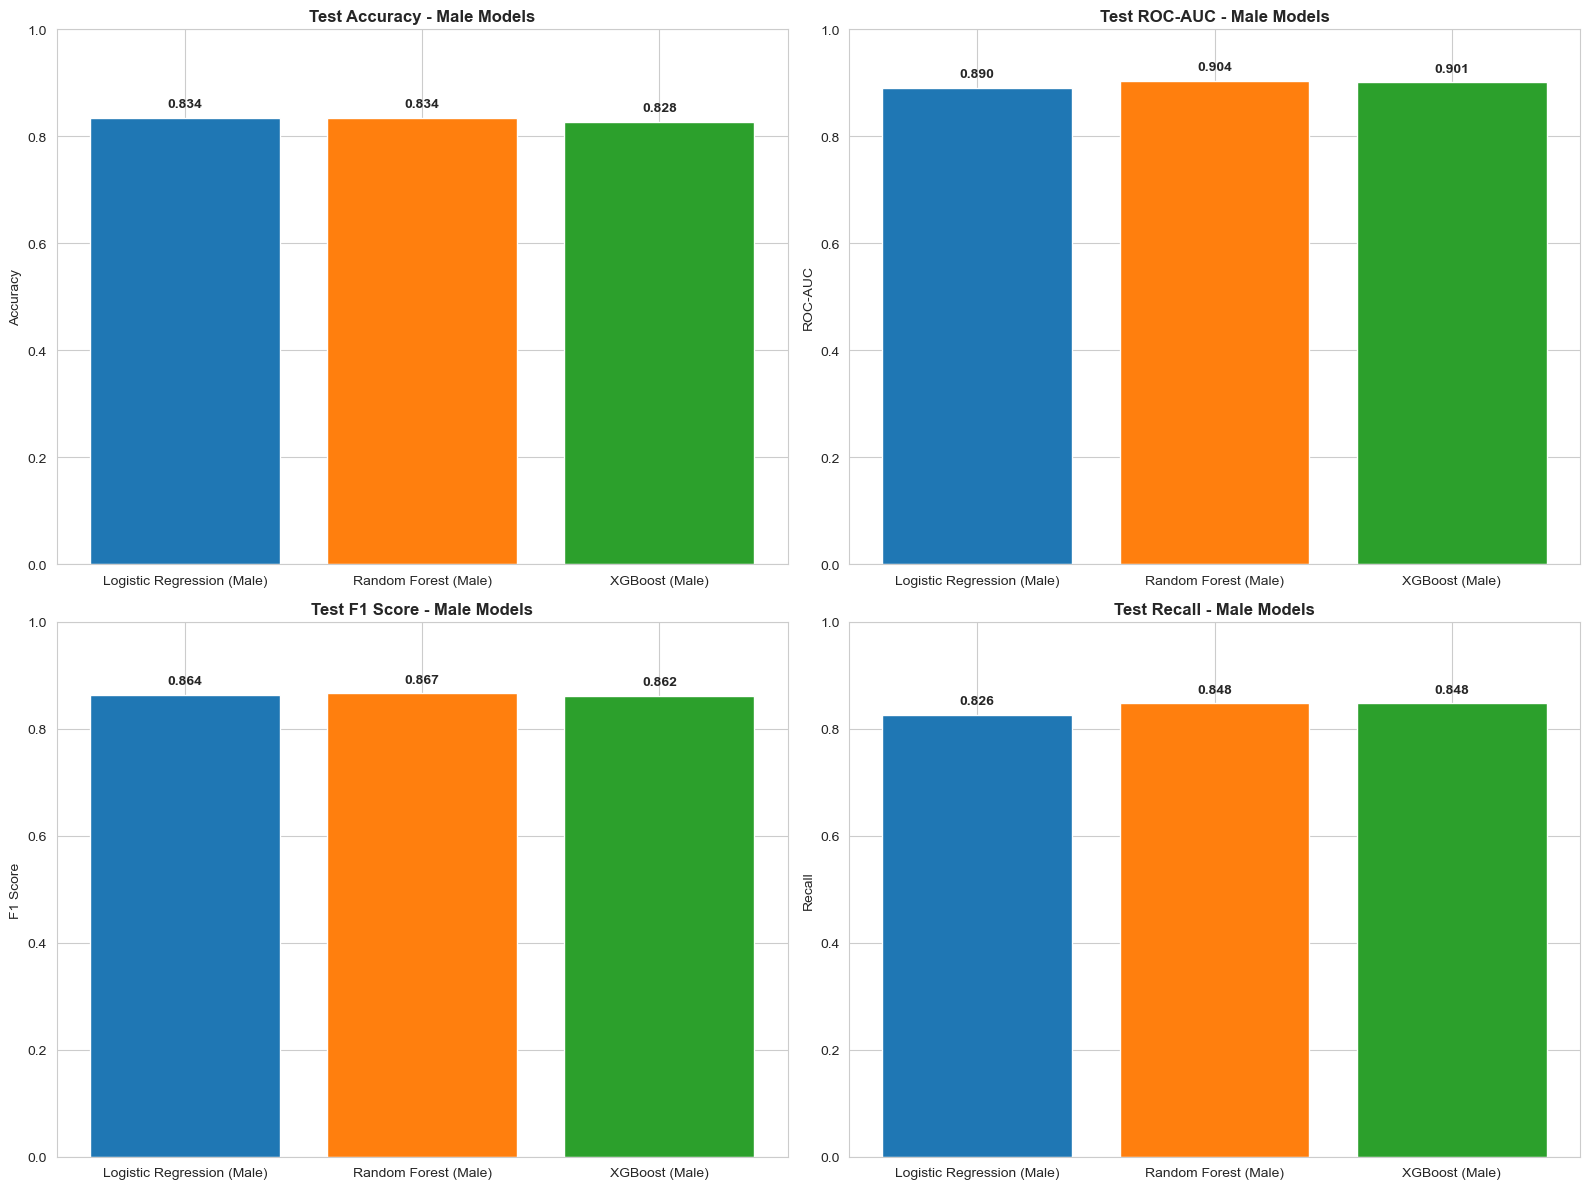


BEST MALE MODEL: Random Forest (Male)
Test Recall (Sensitivity): 0.8478
Test ROC-AUC: 0.9042


In [44]:
# Plot the comparison results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Test Accuracy
axes[0, 0].bar(male_results["Model"], male_results["Test_Accuracy"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[0, 0].set_title("Test Accuracy - Male Models", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(male_results["Test_Accuracy"]):
    axes[0, 0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

# Test ROC-AUC
axes[0, 1].bar(male_results["Model"], male_results["Test_ROC_AUC"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[0, 1].set_title("Test ROC-AUC - Male Models", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("ROC-AUC")
axes[0, 1].set_ylim([0, 1])
for i, v in enumerate(male_results["Test_ROC_AUC"]):
    axes[0, 1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

# Test F1 Score
axes[1, 0].bar(male_results["Model"], male_results["Test_F1"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1, 0].set_title("Test F1 Score - Male Models", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("F1 Score")
axes[1, 0].set_ylim([0, 1])
for i, v in enumerate(male_results["Test_F1"]):
    axes[1, 0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

# Test Recall
axes[1, 1].bar(male_results["Model"], male_results["Test_Recall"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1, 1].set_title("Test Recall - Male Models", fontsize=12, fontweight="bold")
axes[1, 1].set_ylabel("Recall")
axes[1, 1].set_ylim([0, 1])
for i, v in enumerate(male_results["Test_Recall"]):
    axes[1, 1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("images/model_comparison_for_male.png", dpi=1200, bbox_inches="tight")
plt.show()

# Identify best male model
best_male_idx = male_results["Test_Recall"].idxmax()
best_male_model_name = male_results.loc[best_male_idx, "Model"]
print(f"\n{"="*80}")
print(f"BEST MALE MODEL: {best_male_model_name}")
print(f"Test Recall (Sensitivity): {round(male_results.loc[best_male_idx, 'Test_Recall'],4)}")
print(f"Test ROC-AUC: {round(male_results.loc[best_male_idx, "Test_ROC_AUC"],4)}")
print(f"{"="*80}")

#### Model Performance Evaluation - Male Dataset

Three classification algorithms, **Logistic Regression**, **Random Forest**, and **XGBoost**, were evaluated on the male dataset (n = **725**) to predict heart disease presence. Performance was assessed using multiple metrics, including **accuracy**, **ROC-AUC**, **F1 score**, and **recall (sensitivity)**, with particular emphasis on recall given the clinical imperative to minimize false negatives in disease detection.

##### **Comparative Model Performance**:

All three models demonstrated strong and comparable performance across evaluation metrics. Test accuracy was nearly identical across models, with Logistic Regression and Random Forest both achieving **83.4%** and XGBoost slightly lower at **82.8%**. ROC-AUC scores were consistently high, ranging from **0.890** (Logistic Regression) to **0.904** (Random Forest) and **0.901** (XGBoost), indicating excellent discrimination between disease-positive and disease-negative cases.

F1 scores, representing the harmonic mean of precision and recall, showed minimal variation: Logistic Regression (**0.864**), Random Forest (**0.867**), and XGBoost (**0.862**). This consistency suggests balanced performance in both identifying true positives and minimizing false positives across all models.

##### **Sensitivity Analysis**:

Recall (sensitivity), the critical metric for medical screening applications, revealed notable differences between models. Random Forest and XGBoost both achieved the highest test recall of **84.8%**, successfully identifying approximately **85%** of disease-positive cases. Logistic Regression demonstrated marginally lower sensitivity at **82.6%**, representing a **2.2** percentage point difference that could translate to additional missed diagnoses in clinical practice.

##### **Model Selection**:

Based on the comprehensive evaluation, Random Forest was selected as the optimal model for the male dataset, achieving a test recall of **84.78%** and ROC-AUC of **90.42%**. While XGBoost demonstrated equivalent recall performance, Random Forest's superior ROC-AUC score (0.904 vs. 0.901) and marginally higher F1 score (0.867 vs. 0.862) provide slightly better overall discrimination and balanced performance. The model's ability to correctly identify nearly 85% of disease cases while maintaining high specificity makes it well-suited for clinical decision support in the male population.

### 5.3 Train Models on Female Dataset

In [45]:
# ============================================================================
# LOGISTIC REGRESSION - FEMALE DATASET
# ============================================================================

print("="*80)
print("TRAINING LOGISTIC REGRESSION - FEMALE DATASET")
print("="*80)

# Initialize model
logistic_regression_female = LogisticRegression(random_state=RANDOM_STATE)

# Randomized Search with Cross-Validation
logistic_regression_search_female = RandomizedSearchCV(
    logistic_regression_female, 
    logistic_regression_param_grid, 
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="recall",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit the model
print("\nPerforming hyperparameter tuning for Logistic Regression on Female Dataset...")
logistic_regression_search_female.fit(X_female_train_resampled, y_female_train_resampled)

# Best parameters
print("\nBest parameters found:")
print(logistic_regression_search_female.best_params_)
print(f"\nBest cross-validation Recall (Sensitivity) score: {round(logistic_regression_search_female.best_score_,4)}")

# Get the best model
logistic_regression_female_best = logistic_regression_search_female.best_estimator_

# Evaluate
logistic_regression_female_metrics, logistic_regression_female_pred, logistic_regression_female_proba = evaluate_model(
    logistic_regression_female_best, X_female_train_resampled, y_female_train_resampled,
    X_female_test_scaled, y_female_test, "Logistic Regression (Female)"
)

print("\n" + "="*80)
print("LOGISTIC REGRESSION - FEMALE DATASET RESULTS")
print("="*80)
for key, value in logistic_regression_female_metrics.items():
    if key != "Model":
        print(f"{key:20}: {value:.4f}")

TRAINING LOGISTIC REGRESSION - FEMALE DATASET

Performing hyperparameter tuning for Logistic Regression on Female Dataset...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
{'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 1000, 'class_weight': None, 'C': 1}

Best cross-validation Recall (Sensitivity) score: 0.8696

LOGISTIC REGRESSION - FEMALE DATASET RESULTS
Train_Accuracy      : 0.8947
Test_Accuracy       : 0.8462
Train_Precision     : 0.8947
Test_Precision      : 0.6667
Train_Recall        : 0.8947
Test_Recall         : 0.8000
Train_F1            : 0.8947
Test_F1             : 0.7273
Train_ROC_AUC       : 0.9492
Test_ROC_AUC        : 0.8379


In [46]:
# ============================================================================
# RANDOM FOREST - FEMALE DATASET
# ============================================================================

print("="*80)
print("TRAINING RANDOM FOREST - FEMALE DATASET")
print("="*80)

# Initialize model
random_forest_female = RandomForestClassifier(random_state=RANDOM_STATE)

# Randomized Search with Cross-Validation
random_forest_search_female = RandomizedSearchCV(
    random_forest_female, 
    random_forest_param_grid, 
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="recall",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit the model
print("\nPerforming hyperparameter tuning for Random Forest for Female dataset...")
random_forest_search_female.fit(X_female_train_resampled, y_female_train_resampled)

# Best parameters
print("\nBest parameters found:")
print(random_forest_search_female.best_params_)
print(f"\nBest cross-validation Recall (Sensitivity) score: {round(random_forest_search_female.best_score_,4)}")

# Get the best model
random_forest_female_best = random_forest_search_female.best_estimator_

# Evaluate
random_forest_female_metrics, random_forest_female_pred, random_forest_female_proba = evaluate_model(
    random_forest_female_best, X_female_train_resampled, y_female_train_resampled,
    X_female_test_scaled, y_female_test, "Random Forest (Female)"
)

print("\n" + "="*80)
print("RANDOM FOREST - FEMALE DATASET RESULTS")
print("="*80)
for key, value in random_forest_female_metrics.items():
    if key != "Model":
        print(f"{key:20}: {value:.4f}")

TRAINING RANDOM FOREST - FEMALE DATASET

Performing hyperparameter tuning for Random Forest for Female dataset...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 40, 'bootstrap': False}

Best cross-validation Recall (Sensitivity) score: 0.8779

RANDOM FOREST - FEMALE DATASET RESULTS
Train_Accuracy      : 0.9825
Test_Accuracy       : 0.7179
Train_Precision     : 0.9911
Test_Precision      : 0.4667
Train_Recall        : 0.9737
Test_Recall         : 0.7000
Train_F1            : 0.9823
Test_F1             : 0.5600
Train_ROC_AUC       : 0.9986
Test_ROC_AUC        : 0.7690


In [47]:
# ============================================================================
# XGBOOST - FEMALE DATASET
# ============================================================================

print("="*80)
print("TRAINING XGBOOST - FEMALE DATASET")
print("="*80)

# Initialize model
xgb_female = XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")

# Randomized Search with Cross-Validation
xgb_search_female = RandomizedSearchCV(
    xgb_female, 
    xgb_param_grid, 
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="recall",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit the model
print("\nPerforming hyperparameter tuning...")
xgb_search_female.fit(X_female_train_resampled, y_female_train_resampled)

# Best parameters
print("\nBest parameters found:")
print(xgb_search_female.best_params_)
print(f"\nBest cross-validation Recall (Sensitivity) score: {round(xgb_search_female.best_score_,4)}")

# Get best model
xgb_female_best = xgb_search_female.best_estimator_

# Evaluate
xgb_female_metrics, xgb_female_pred, xgb_female_proba = evaluate_model(
    xgb_female_best, X_female_train_resampled, y_female_train_resampled,
    X_female_test_scaled, y_female_test, "XGBoost (Female)"
)

print("\n" + "="*80)
print("XGBOOST - FEMALE DATASET RESULTS")
print("="*80)
for key, value in xgb_female_metrics.items():
    if key != "Model":
        print(f"{key:20}: {value:.4f}")

TRAINING XGBOOST - FEMALE DATASET

Performing hyperparameter tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
{'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}

Best cross-validation Recall (Sensitivity) score: 0.9126

XGBOOST - FEMALE DATASET RESULTS
Train_Accuracy      : 1.0000
Test_Accuracy       : 0.7692
Train_Precision     : 1.0000
Test_Precision      : 0.5385
Train_Recall        : 1.0000
Test_Recall         : 0.7000
Train_F1            : 1.0000
Test_F1             : 0.6087
Train_ROC_AUC       : 1.0000
Test_ROC_AUC        : 0.8034


In [48]:
# Compare the results of female models
print("="*80)
print("FEMALE DATASET - MODEL COMPARISON")
print("="*80)

female_results = pd.DataFrame([logistic_regression_female_metrics, random_forest_female_metrics, xgb_female_metrics])
female_results


FEMALE DATASET - MODEL COMPARISON


,Model,Train_Accuracy,Test_Accuracy,Train_Precision,Test_Precision,Train_Recall,Test_Recall,Train_F1,Test_F1,Train_ROC_AUC,Test_ROC_AUC
0,Logistic Regression (Female),0.894737,0.846154,0.894737,0.666667,0.894737,0.8,0.894737,0.727273,0.949215,0.837931
1,Random Forest (Female),0.982456,0.717949,0.991071,0.466667,0.973684,0.7,0.982301,0.560000,0.998615,0.768966
2,XGBoost (Female),1.000000,0.769231,1.000000,0.538462,1.000000,0.7,1.000000,0.608696,1.000000,0.803448


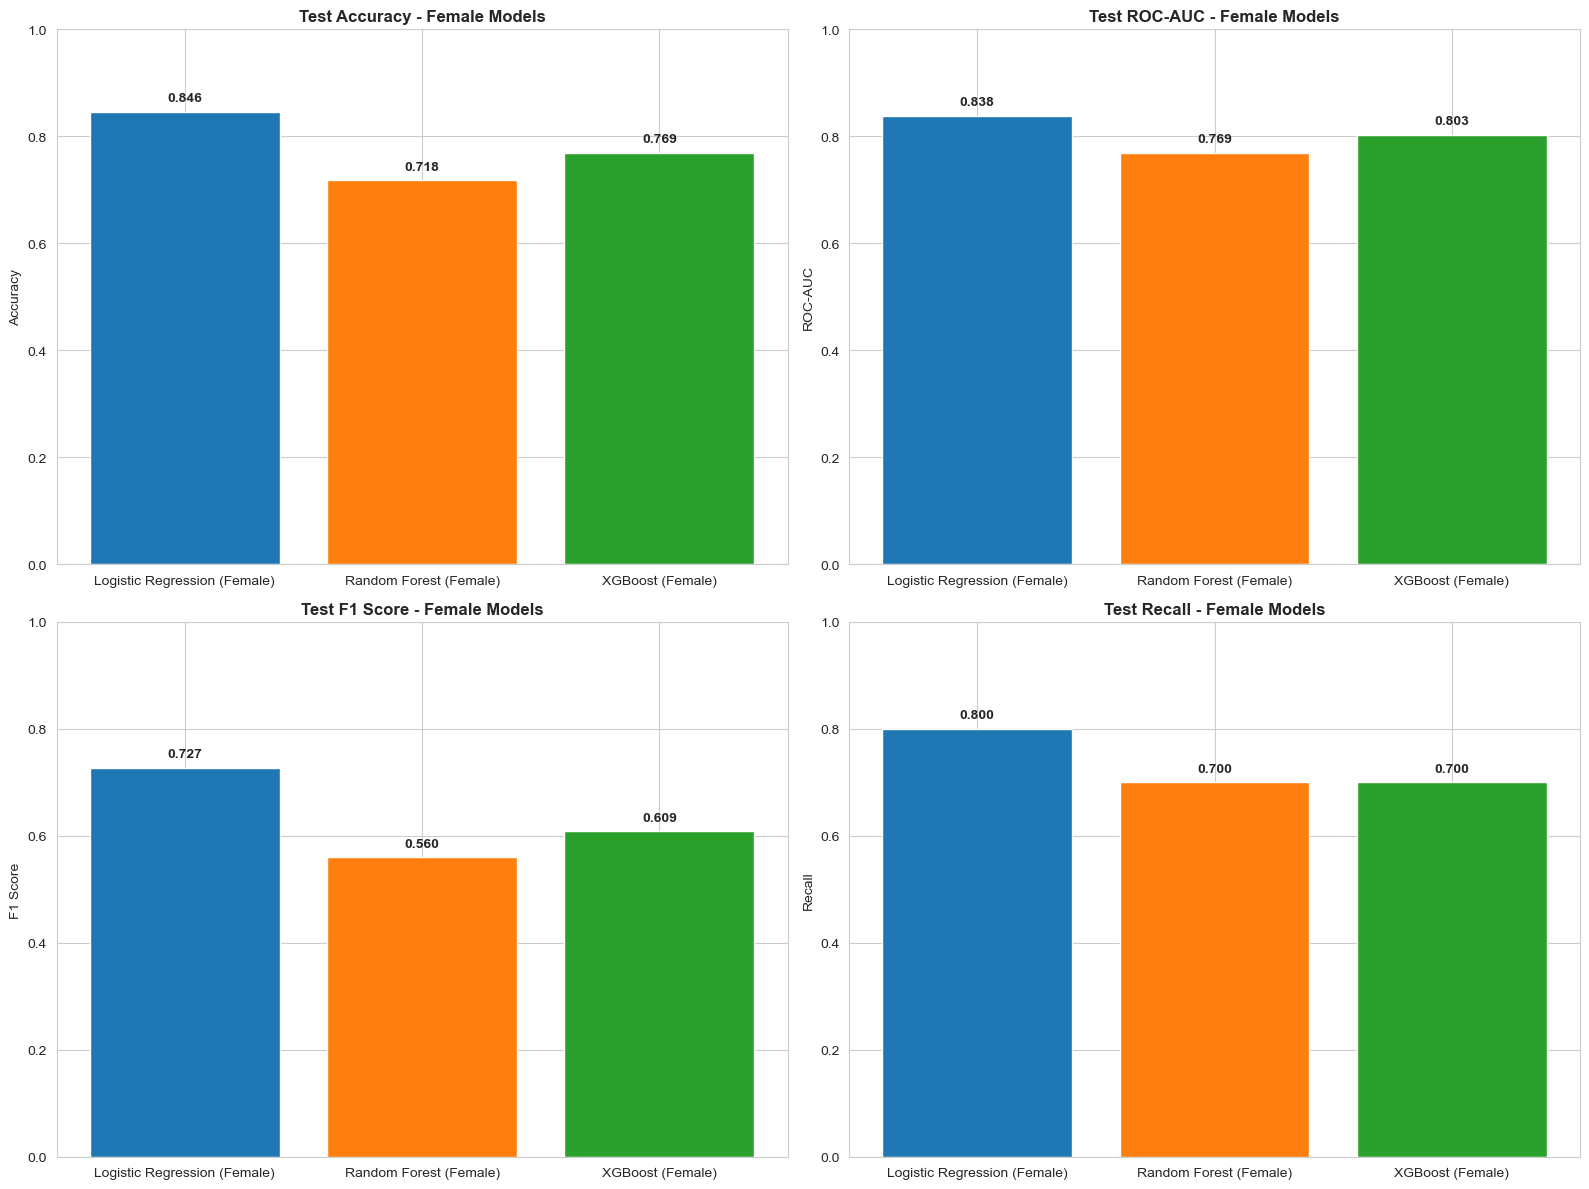


BEST FEMALE MODEL: Logistic Regression (Female)
Test Recall (Sensitivity): 0.8
Test ROC-AUC: 0.8379


In [49]:
# Plot the comparison results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Test Accuracy
axes[0, 0].bar(female_results["Model"], female_results["Test_Accuracy"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[0, 0].set_title("Test Accuracy - Female Models", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(female_results["Test_Accuracy"]):
    axes[0, 0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

# Test ROC-AUC
axes[0, 1].bar(female_results["Model"], female_results["Test_ROC_AUC"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[0, 1].set_title("Test ROC-AUC - Female Models", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("ROC-AUC")
axes[0, 1].set_ylim([0, 1])
for i, v in enumerate(female_results["Test_ROC_AUC"]):
    axes[0, 1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

# Test F1 Score
axes[1, 0].bar(female_results["Model"], female_results["Test_F1"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1, 0].set_title("Test F1 Score - Female Models", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("F1 Score")
axes[1, 0].set_ylim([0, 1])
for i, v in enumerate(female_results["Test_F1"]):
    axes[1, 0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

# Test Recall
axes[1, 1].bar(female_results["Model"], female_results["Test_Recall"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1, 1].set_title("Test Recall - Female Models", fontsize=12, fontweight="bold")
axes[1, 1].set_ylabel("Recall")
axes[1, 1].set_ylim([0, 1])
for i, v in enumerate(female_results["Test_Recall"]):
    axes[1, 1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("images/model_comparison_for_female.png", dpi=1200, bbox_inches="tight")
plt.show()

# Identify best female model
best_female_idx = female_results["Test_Recall"].idxmax()
best_female_model_name = female_results.loc[best_female_idx, "Model"]
print(f"\n{"="*80}")
print(f"BEST FEMALE MODEL: {best_female_model_name}")
print(f"Test Recall (Sensitivity): {round(female_results.loc[best_female_idx, 'Test_Recall'],4)}")
print(f"Test ROC-AUC: {round(female_results.loc[best_female_idx, "Test_ROC_AUC"],4)}")
print(f"{"="*80}")

#### Model Performance Evaluation - Female Dataset

Same three classification algorithms, **Logistic Regression**, **Random Forest**, and **XGBoost**, were evaluated on the female dataset (n = **193**) as well to predict heart disease presence. Given the substantially smaller sample size compared to the male dataset and the severe class imbalance (**74.09%** disease-negative), model performance was assessed with particular attention to generalization capability and sensitivity.

##### **Comparative Model Performance**:

Model performance varied considerably across the female dataset, with notable differences in all evaluation metrics. Test accuracy ranged from **71.8%** (Random Forest) to **84.6%** (Logistic Regression), with XGBoost achieving intermediate performance at **76.9%**. This **12.8** percentage point accuracy gap suggests differential model complexity and potential overfitting in ensemble methods when faced with limited training samples.

ROC-AUC scores demonstrated a similar pattern: Logistic Regression achieved **0.838**, XGBoost **0.803**, and Random Forest **0.769**. The lower ROC-AUC values for ensemble methods indicate reduced discrimination capability, likely attributable to the limited sample size constraining the effectiveness of tree-based algorithms that typically require larger datasets for optimal performance.

##### **Sensitivity and F1 Score Analysis**:

Recall (sensitivity) exhibited substantial variation across models, revealing critical differences in disease detection capability. Logistic Regression achieved the highest test recall at **80.0%**, successfully identifying **80%** of disease-positive cases. In contrast, Random Forest and XGBoost both demonstrated notably lower sensitivity at **70.0%**, representing a **10** percentage point deficit that could result in one additional missed diagnosis for every ten disease-positive patients.

F1 scores reflected these disparities: Logistic Regression achieved **0.727**, substantially outperforming XGBoost (**0.609**) and Random Forest (**0.560**). The lower F1 scores for ensemble methods suggest an unfavorable precision-recall tradeoff, possibly due to overfitting on the limited training data or difficulty in generalizing patterns from the minority disease-positive class (n = 50).

##### **Model Selection and Clinical Implications**:

Based on this comprehensive evaluation, **Logistic Regression** was selected as the optimal model for the female dataset, achieving a test recall of **80.0%** and ROC-AUC of **83.79%**. The model's superior performance across all metrics, particularly its 10 percentage point advantage in sensitivity, makes it the most suitable choice for clinical application in the female population. The simpler linear model architecture appears better suited to the limited sample size, demonstrating superior generalization compared to more complex ensemble methods that likely suffered from overfitting. This finding underscores the importance of matching model complexity to dataset characteristics, particularly when working with smaller, imbalanced datasets.

### 5.4 Stage 1 Summary and Best Model Selection

In [50]:
# Let's save the best models for male and female datasets
best_male_model = random_forest_male_best
best_male_model_type = "rf"

best_female_model = logistic_regression_female_best
best_female_model_type = "lr"



					===> Feature Importance Analysis<===


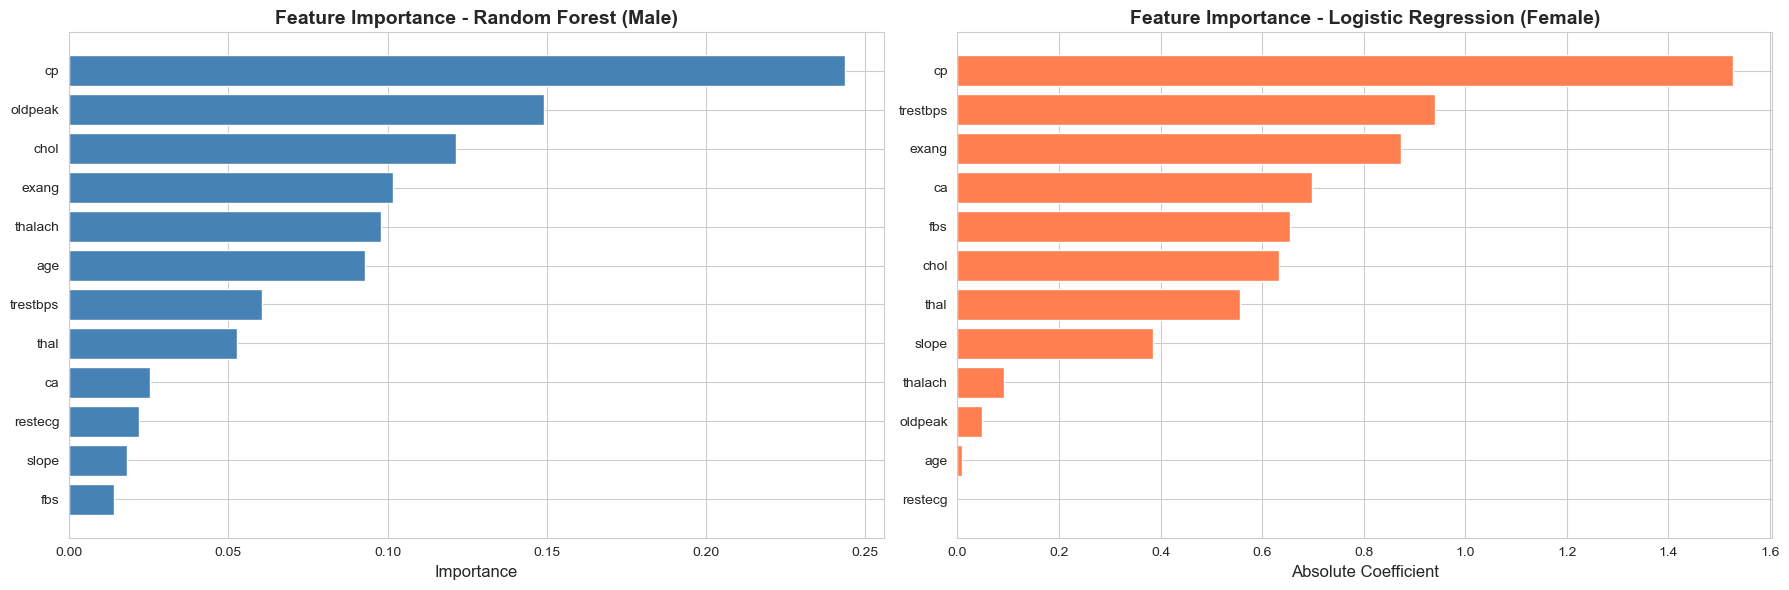


Top 5 Most Important Features:

Male Model:
   feature  importance
1       cp    0.243515
8  oldpeak    0.149152
3     chol    0.121465
7    exang    0.101764
6  thalach    0.097876

Female Model:
     feature  importance
1         cp    1.527941
2   trestbps    0.939827
7      exang    0.872659
10        ca    0.698501
4        fbs    0.655743


In [51]:
# Feature importance analysis for the best models
print("\n\n\t\t\t\t\t===> Feature Importance Analysis<===")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Male model feature importance
male_importance = pd.DataFrame({
        "feature": X_male.columns,
        "importance": best_male_model.feature_importances_
}).sort_values("importance", ascending=False)
    
axes[0].barh(male_importance["feature"], male_importance["importance"], color="steelblue")
axes[0].set_xlabel("Importance", fontsize=12)
axes[0].set_title(f"Feature Importance - {best_male_model_name}", fontsize=14, fontweight="bold")
axes[0].invert_yaxis()

# Female model feature importance

female_importance = pd.DataFrame({
    "feature": X_female.columns,
    "importance": np.abs(best_female_model.coef_[0])
}).sort_values("importance", ascending=False)

axes[1].barh(female_importance["feature"], female_importance["importance"], color="coral")
axes[1].set_xlabel("Absolute Coefficient", fontsize=12)
axes[1].set_title(f"Feature Importance - {best_female_model_name}", fontsize=14, fontweight="bold")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("images/Feature_Importance_Analysis.png", dpi=1200, bbox_inches="tight")
plt.show()

print("\nTop 5 Most Important Features:")
print("\nMale Model:")
print(male_importance.head())
print("\nFemale Model:")
print(female_importance.head())

## 6. STAGE 2: Fair Cross-Gender Comparison with Sampling Strategies

### 6.1 Scenario A - Oversampling Strategy (Match Male Count)

In [52]:
print("\n\n\t\t\t\t\t===> Stage 2 Analysis - Oversampling Strategy (Match Male Count)<===")

# Determine target sample size (male count)
male_sample_count = len(df_male)
female_sample_count = len(df_female)

print(f"Original Male samples: {male_sample_count}")
print(f"Original Female samples: {female_sample_count}")
print(f"\nTarget sample size for both: {male_sample_count}")

# Oversample female dataset to match male count
# We"ll use SMOTE on the entire female dataset first, then split
print("\nOversampling female dataset...")
smote_oversample = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, female_sample_count-1))

# Calculate how many samples we need
samples_needed = male_sample_count - female_sample_count
sampling_strategy = {0: int(female_target_counts[0] * (male_sample_count / female_sample_count)),
                     1: int(female_target_counts[1] * (male_sample_count / female_sample_count))}

# Apply SMOTE to female data
smote_female_oversamplign = SMOTE(sampling_strategy=sampling_strategy, random_state=RANDOM_STATE, 
                          k_neighbors=min(5, min(female_target_counts)-1))
X_female_oversampled, y_female_oversampled = smote_female_oversamplign.fit_resample(X_female, y_female)

print(f"Female dataset after oversampling: {len(X_female_oversampled)} samples")
print(f"Target distribution: {pd.Series(y_female_oversampled).value_counts().to_dict()}")

# Split into train/test
X_male_train, X_male_test, y_male_train, y_male_test = train_test_split(
    X_male, y_male, test_size=TEST_SIZE, stratify=y_male, random_state=RANDOM_STATE
)

X_female_train_oversampling, X_female_test_oversampling, y_female_train_oversampling, y_female_test_oversampling = train_test_split(
    X_female_oversampled, y_female_oversampled, test_size=TEST_SIZE, stratify=y_female_oversampled, random_state=RANDOM_STATE
)

# Scale features
scaler_male_oversampling = StandardScaler()
scaler_female_oversampling = StandardScaler()

X_male_train_scaled = scaler_male_oversampling.fit_transform(X_male_train)
X_male_test_scaled = scaler_male_oversampling.transform(X_male_test)

X_female_train_oversampling_scaled = scaler_female_oversampling.fit_transform(X_female_train_oversampling)
X_female_test_oversampling_scaled = scaler_female_oversampling.transform(X_female_test_oversampling)



					===> Stage 2 Analysis - Oversampling Strategy (Match Male Count)<===
Original Male samples: 725
Original Female samples: 193

Target sample size for both: 725

Oversampling female dataset...
Female dataset after oversampling: 724 samples
Target distribution: {0: 537, 1: 187}


In [53]:
# L3t's check the sample size 
print(f"\nMale training set: {X_male_train_scaled.shape[0]} samples")
print(f"Male test set: {X_male_test_scaled.shape[0]} samples")
print(f"\nFemale training set: {X_female_train_oversampling_scaled.shape[0]} samples")
print(f"Female test set: {X_female_test_oversampling_scaled.shape[0]} samples")


Male training set: 580 samples
Male test set: 145 samples

Female training set: 579 samples
Female test set: 145 samples


In [54]:
# Train best models on oversampled data
print("="*80)
print("TRAINING BEST MODELS ON OVERSAMPLED DATA")
print("="*80)

# Clone the best models with their optimal parameters
from sklearn.base import clone

# Male model
print(f"\nTraining {best_male_model_name} on oversampled male data...")
male_model_oversampling = clone(best_male_model)
male_model_oversampling.fit(X_male_train_scaled, y_male_train)

male_metrics_oversampling, male_pred_oversampling, male_proba_oversampling = evaluate_model(
    male_model_oversampling, X_male_train_scaled, y_male_train,
    X_male_test_scaled, y_male_test, f"{best_male_model_name} (Oversampled)"
)

print("\nMale Model (Oversampled) Results:")
for key, value in male_metrics_oversampling.items():
    if key != "Model":
        print(f"  {key:20}: {value:.4f}")

TRAINING BEST MODELS ON OVERSAMPLED DATA

Training Random Forest (Male) on oversampled male data...

Male Model (Oversampled) Results:
  Train_Accuracy      : 0.9086
  Test_Accuracy       : 0.8138
  Train_Precision     : 0.8922
  Test_Precision      : 0.8155
  Train_Recall        : 0.9727
  Test_Recall         : 0.9130
  Train_F1            : 0.9307
  Test_F1             : 0.8615
  Train_ROC_AUC       : 0.9779
  Test_ROC_AUC        : 0.9137


In [55]:
# Now, train the female model
print(f"\nTraining {best_female_model_name} on oversampled female data...")
female_model_oversampling = clone(best_female_model)
female_model_oversampling.fit(X_female_train_oversampling_scaled, y_female_train_oversampling)

female_metrics_oversampling, female_pred_oversampling, female_proba_oversampling = evaluate_model(
    female_model_oversampling, X_female_train_oversampling_scaled, y_female_train_oversampling,
    X_female_test_oversampling_scaled, y_female_test_oversampling, f"{best_female_model_name} (Oversampled)"
)

print("\nFemale Model (Oversampled) Results:")
for key, value in female_metrics_oversampling.items():
    if key != "Model":
        print(f"  {key:20}: {value:.4f}")


Training Logistic Regression (Female) on oversampled female data...

Female Model (Oversampled) Results:
  Train_Accuracy      : 0.9171
  Test_Accuracy       : 0.8690
  Train_Precision     : 0.8984
  Test_Precision      : 0.8214
  Train_Recall        : 0.7667
  Test_Recall         : 0.6216
  Train_F1            : 0.8273
  Test_F1             : 0.7077
  Train_ROC_AUC       : 0.9579
  Test_ROC_AUC        : 0.9129


### 6.2 Scenario B - Undersampling Strategy (Match Female Count)

In [56]:
# ============================================================================
# STAGE 2B: UNDERSAMPLING STRATEGY
# ============================================================================
print("\n\n\t\t\t\t\t===> Stage 2 Analysis - Undersampling Strategy (Match Female Count)<===")
print(f"Original Male samples: {male_sample_count}")
print(f"Original Female samples: {female_sample_count}")
print(f"\nTarget sample size for both: {female_sample_count}")

# Undersample the male dataset to match the female count
print("\nUndersampling male dataset...")
sampling_strategy_undersampling = {0: int(male_target_counts[0] * (female_sample_count / male_sample_count)),
                           1: int(male_target_counts[1] * (female_sample_count / male_sample_count))}

rus = RandomUnderSampler(sampling_strategy=sampling_strategy_undersampling, random_state=RANDOM_STATE)
X_male_undersampled, y_male_undersampled = rus.fit_resample(X_male, y_male)

print(f"Male dataset after undersampling: {len(X_male_undersampled)} samples")
print(f"Target distribution: {pd.Series(y_male_undersampled).value_counts().to_dict()}")

print(f"\nFemale dataset: {len(X_female)} samples")
print(f"Target distribution: {pd.Series(y_female).value_counts().to_dict()}")



					===> Stage 2 Analysis - Undersampling Strategy (Match Female Count)<===
Original Male samples: 725
Original Female samples: 193

Target sample size for both: 193

Undersampling male dataset...
Male dataset after undersampling: 192 samples
Target distribution: {1: 121, 0: 71}

Female dataset: 193 samples
Target distribution: {0: 143, 1: 50}


In [57]:
# Split into train/test
X_male_train_undersampled, X_male_test_undersampled, y_male_train_undersampled, y_male_test_undersampled = train_test_split(
    X_male_undersampled, y_male_undersampled, test_size=TEST_SIZE, stratify=y_male_undersampled, random_state=RANDOM_STATE
)

X_female_train_under, X_female_test_under, y_female_train_under, y_female_test_under = train_test_split(
    X_female, y_female, test_size=TEST_SIZE, stratify=y_female, random_state=RANDOM_STATE
)

# Scale features
scaler_male_undersampling = StandardScaler()
scaler_female_undersampling = StandardScaler()

X_male_train_undersampled_scaled = scaler_male_undersampling.fit_transform(X_male_train_undersampled)
X_male_test_undersampled_scaled = scaler_male_undersampling.transform(X_male_test_undersampled)

X_female_train_scaled = scaler_female_undersampling.fit_transform(X_female_train)
X_female_test_scaled = scaler_female_undersampling.transform(X_female_test)

In [58]:
print(f"Male training set: {X_male_train_undersampled_scaled.shape[0]} samples")
print(f"Male test set: {X_male_test_undersampled_scaled.shape[0]} samples")
print(f"\nFemale training set: {X_female_train_scaled.shape[0]} samples")
print(f"Female test set: {X_female_test_scaled.shape[0]} samples")

Male training set: 153 samples
Male test set: 39 samples

Female training set: 154 samples
Female test set: 39 samples


In [59]:
# Train best models on undersampled data

# Clone the male best model
male_model_undersampling = clone(best_male_model)
male_model_undersampling.fit(X_male_train_undersampled_scaled, y_male_train_undersampled)

male_metrics_undersampling, male_pred_undersampling, male_proba_undersampling = evaluate_model(
    male_model_undersampling, X_male_train_undersampled_scaled, y_male_train_undersampled,
    X_male_test_undersampled_scaled, y_male_test_undersampled, f"{best_male_model_name} (Undersampled)"
)

print("\nMale Model (Undersampled) Results:")
for key, value in male_metrics_undersampling.items():
    if key != "Model":
        print(f"  {key:20}: {value:.4f}")

# Female model
print(f"\nTraining {best_female_model_name} on undersampled female data...")
female_model_undersampling = clone(best_female_model)
female_model_undersampling.fit(X_female_train_scaled, y_female_train)

female_metrics_undersampling, female_pred_undersampling, female_proba_undersampling = evaluate_model(
    female_model_undersampling, X_female_train_scaled, y_female_train,
    X_female_test_scaled, y_female_test, f"{best_female_model_name} (Undersampled)"
)

print("\nFemale Model (Undersampled) Results:")
for key, value in female_metrics_undersampling.items():
    if key != "Model":
        print(f"  {key:20}: {value:.4f}")


Male Model (Undersampled) Results:
  Train_Accuracy      : 0.9020
  Test_Accuracy       : 0.7949
  Train_Precision     : 0.8857
  Test_Precision      : 0.8400
  Train_Recall        : 0.9688
  Test_Recall         : 0.8400
  Train_F1            : 0.9254
  Test_F1             : 0.8400
  Train_ROC_AUC       : 0.9799
  Test_ROC_AUC        : 0.7771

Training Logistic Regression (Female) on undersampled female data...

Female Model (Undersampled) Results:
  Train_Accuracy      : 0.8766
  Test_Accuracy       : 0.8718
  Train_Precision     : 0.8000
  Test_Precision      : 0.7273
  Train_Recall        : 0.7000
  Test_Recall         : 0.8000
  Train_F1            : 0.7467
  Test_F1             : 0.7619
  Train_ROC_AUC       : 0.9375
  Test_ROC_AUC        : 0.8379


## 7. Final Analysis and Comparison

### 7.1 Cross-Scenario Comparison

In [60]:
# Compare all scenarios

# Create comparison dataframe
final_comparison_results = pd.DataFrame([
    male_metrics_oversampling,
    female_metrics_oversampling,
    male_metrics_undersampling,
    female_metrics_undersampling
])

print("\nStage 2 Results:")
final_comparison_results


Stage 2 Results:


,Model,Train_Accuracy,Test_Accuracy,Train_Precision,Test_Precision,Train_Recall,Test_Recall,Train_F1,Test_F1,Train_ROC_AUC,Test_ROC_AUC
0,Random Forest (Male) (Oversampled),0.908621,0.813793,0.892231,0.815534,0.972678,0.913043,0.930719,0.861538,0.977938,0.913659
1,Logistic Regression (Female) (Oversampled),0.917098,0.868966,0.898438,0.821429,0.766667,0.621622,0.827338,0.707692,0.957855,0.912913
2,Random Forest (Male) (Undersampled),0.901961,0.794872,0.885714,0.840000,0.968750,0.840000,0.925373,0.840000,0.979898,0.777143
3,Logistic Regression (Female) (Undersampled),0.876623,0.871795,0.800000,0.727273,0.700000,0.800000,0.746667,0.761905,0.937500,0.837931


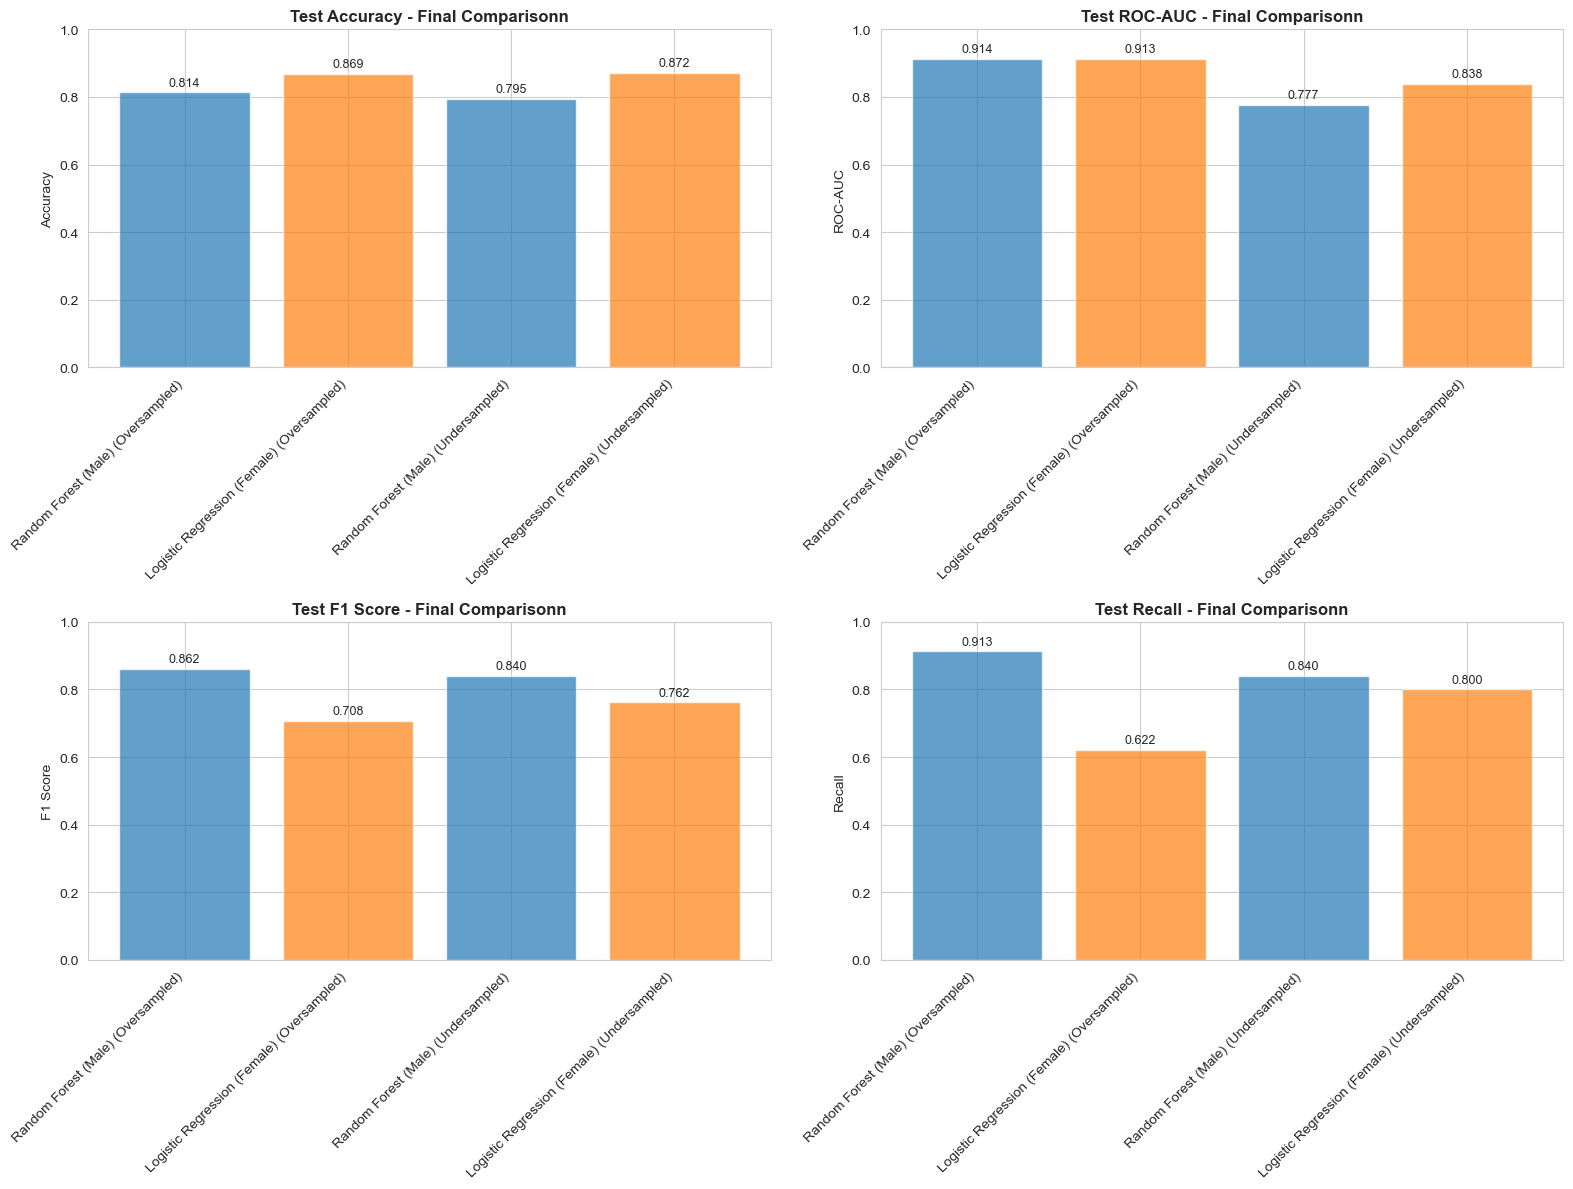

In [61]:
# Plot the combined resulst
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = final_comparison_results["Model"]
x_pos = np.arange(len(models))

# Test Accuracy
axes[0, 0].bar(x_pos, final_comparison_results["Test_Accuracy"], color=["#1f77b4", "#ff7f0e", "#1f77b4", "#ff7f0e"], alpha=0.7)
axes[0, 0].set_title("Test Accuracy - Final Comparisonn", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models, rotation=45, ha="right")
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(final_comparison_results["Test_Accuracy"]):
    axes[0, 0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

# Test ROC-AUC
axes[0, 1].bar(x_pos, final_comparison_results["Test_ROC_AUC"], color=["#1f77b4", "#ff7f0e", "#1f77b4", "#ff7f0e"], alpha=0.7)
axes[0, 1].set_title("Test ROC-AUC - Final Comparisonn", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("ROC-AUC")
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models, rotation=45, ha="right")
axes[0, 1].set_ylim([0, 1])
for i, v in enumerate(final_comparison_results["Test_ROC_AUC"]):
    axes[0, 1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

# Test F1 Score
axes[1, 0].bar(x_pos, final_comparison_results["Test_F1"], color=["#1f77b4", "#ff7f0e", "#1f77b4", "#ff7f0e"], alpha=0.7)
axes[1, 0].set_title("Test F1 Score - Final Comparisonn", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("F1 Score")
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(models, rotation=45, ha="right")
axes[1, 0].set_ylim([0, 1])
for i, v in enumerate(final_comparison_results["Test_F1"]):
    axes[1, 0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

# Test Recall
axes[1, 1].bar(x_pos, final_comparison_results["Test_Recall"], color=["#1f77b4", "#ff7f0e", "#1f77b4", "#ff7f0e"], alpha=0.7)
axes[1, 1].set_title("Test Recall - Final Comparisonn", fontsize=12, fontweight="bold")
axes[1, 1].set_ylabel("Recall")
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(models, rotation=45, ha="right")
axes[1, 1].set_ylim([0, 1])
for i, v in enumerate(final_comparison_results["Test_Recall"]):
    axes[1, 1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("images/Final_coparison_Plots.png", dpi=1200, bbox_inches="tight")
plt.show()

In [62]:
# Analyze sampling strategy impact
print("="*80)
print("SAMPLING STRATEGY IMPACT ANALYSIS")
print("="*80)

# Compare oversampling vs undersampling for each gender
print("\nMale Models:")
print(f" - Oversampling ROC-AUC:  {round(male_metrics_oversampling["Test_ROC_AUC"],4)}")
print(f" - Undersampling ROC-AUC: {round(male_metrics_undersampling["Test_ROC_AUC"],4)}")
print(f" - Difference: {abs(male_metrics_oversampling["Test_ROC_AUC"] - round(male_metrics_undersampling["Test_ROC_AUC"],4))}")

print("\nFemale Models:")
print(f" - Oversampling ROC-AUC:  {round(female_metrics_oversampling["Test_ROC_AUC"],4)}")
print(f" - Undersampling ROC-AUC: {round(female_metrics_undersampling["Test_ROC_AUC"],4)}")
print(f" - Difference: {abs(female_metrics_oversampling["Test_ROC_AUC"] - round(female_metrics_undersampling["Test_ROC_AUC"],4))}")

male_oversampling_improved_results = male_metrics_oversampling["Test_ROC_AUC"] > male_metrics_undersampling["Test_ROC_AUC"]
female_oversampling_improved_results = female_metrics_oversampling["Test_ROC_AUC"] > female_metrics_undersampling["Test_ROC_AUC"]

print(f"\nDid oversampling for male dataset improve the accuracy?", male_oversampling_improved_results)
print(f"Did oversampling for female dataset improve the accuracy?",female_oversampling_improved_results)

SAMPLING STRATEGY IMPACT ANALYSIS

Male Models:
 - Oversampling ROC-AUC:  0.9137
 - Undersampling ROC-AUC: 0.7771
 - Difference: 0.1365587366694011

Female Models:
 - Oversampling ROC-AUC:  0.9129
 - Undersampling ROC-AUC: 0.8379
 - Difference: 0.07501291291291301

Did oversampling for male dataset improve the accuracy? True
Did oversampling for female dataset improve the accuracy? True


### 7.2 Feature Importance Comparison Across Genders and Strategies

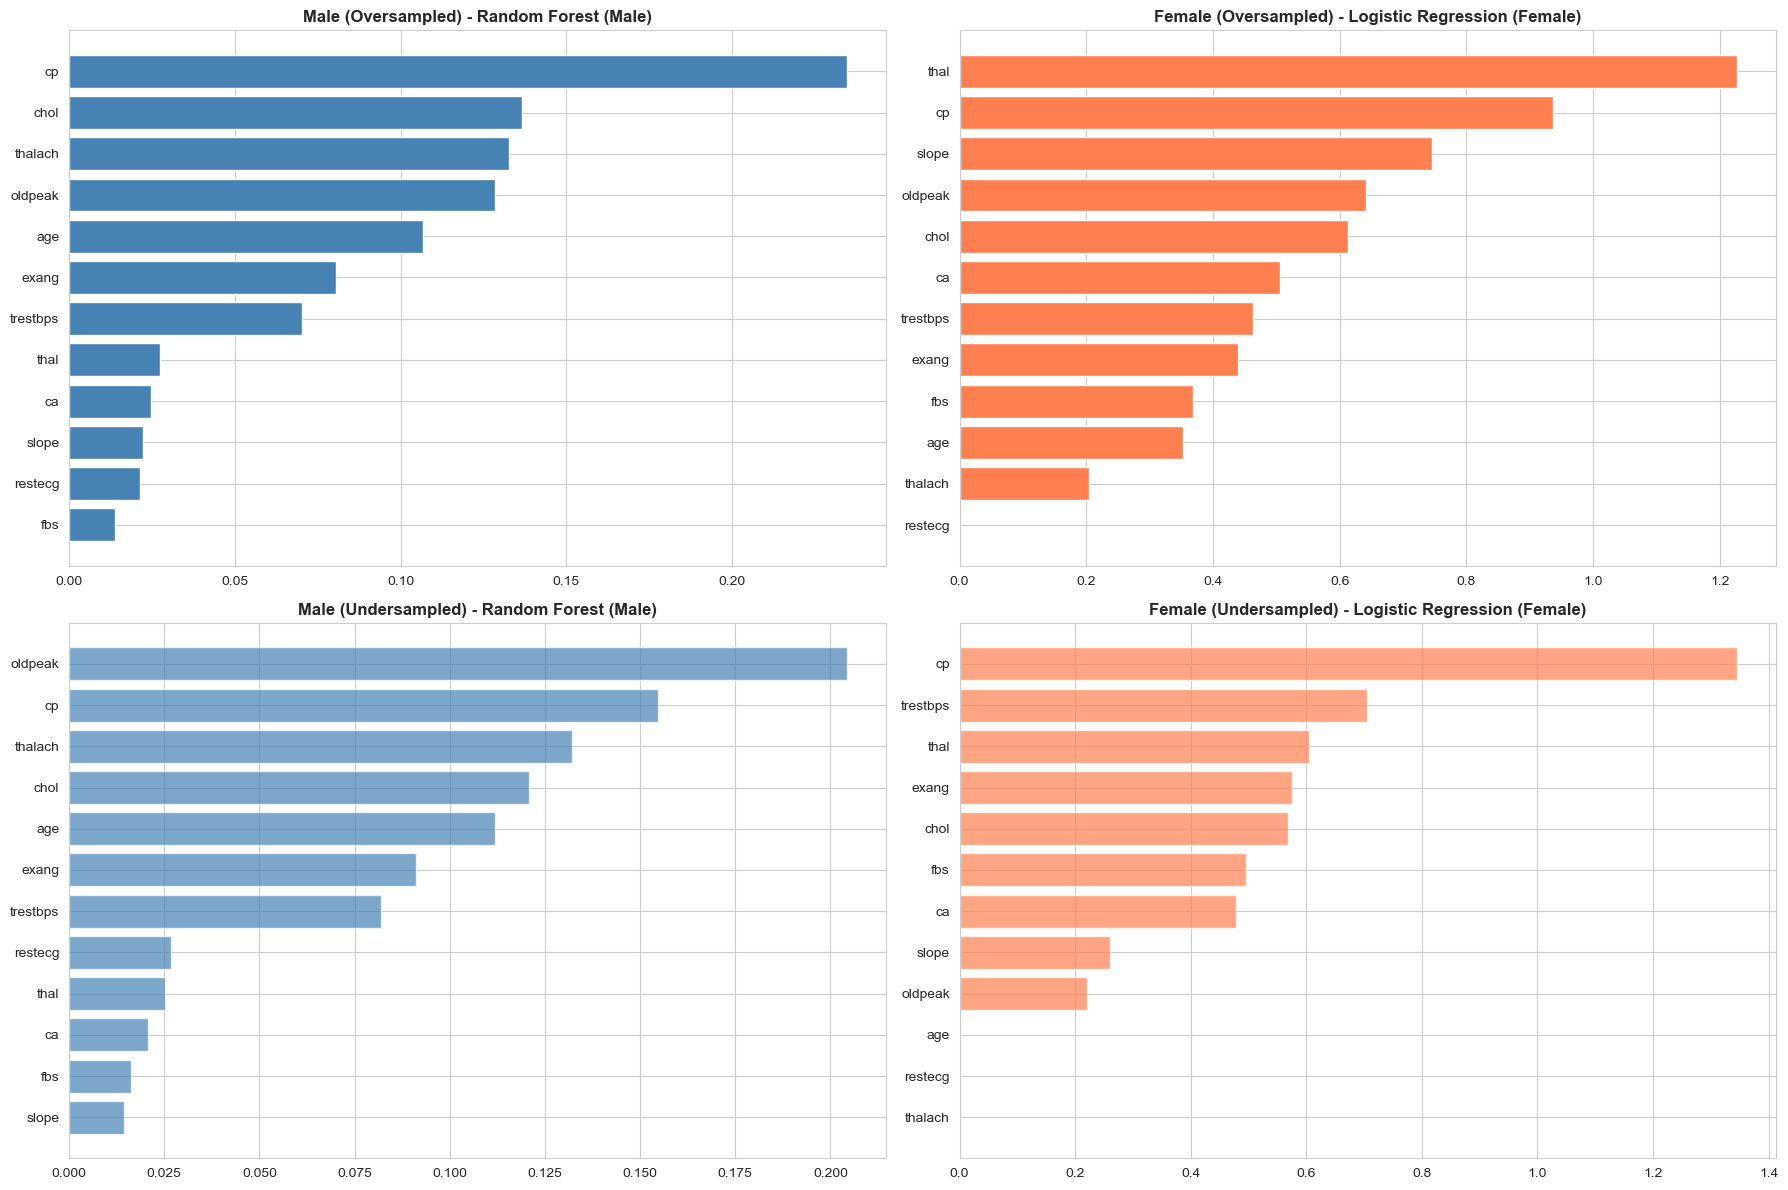

In [63]:
# Compare feature importance across scenarios
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Male Oversampled
male_oversampling_importance = pd.DataFrame({
    "feature": X_male.columns,
    "importance": male_model_oversampling.feature_importances_
}).sort_values("importance", ascending=False)
axes[0, 0].barh(male_oversampling_importance["feature"], male_oversampling_importance["importance"], color="steelblue")
axes[0, 0].set_title(f"Male (Oversampled) - {best_male_model_name}", fontsize=12, fontweight="bold")
axes[0, 0].invert_yaxis()

# Female Oversampled
female_oversampling_importance = pd.DataFrame({
    "feature": X_female.columns,
    "importance": np.abs(female_model_oversampling.coef_[0])
}).sort_values("importance", ascending=False)
axes[0, 1].barh(female_oversampling_importance["feature"], female_oversampling_importance["importance"], color="coral")
axes[0, 1].set_title(f"Female (Oversampled) - {best_female_model_name}", fontsize=12, fontweight="bold")
axes[0, 1].invert_yaxis()

# Male Undersampled
male_undersampling_imporatnce = pd.DataFrame({
    "feature": X_male.columns,
    "importance": male_model_undersampling.feature_importances_
}).sort_values("importance", ascending=False)
axes[1, 0].barh(male_undersampling_imporatnce["feature"], male_undersampling_imporatnce["importance"], color="steelblue", alpha=0.7)
axes[1, 0].set_title(f"Male (Undersampled) - {best_male_model_name}", fontsize=12, fontweight="bold")
axes[1, 0].invert_yaxis()

# Female Undersampled
female_undersampling_imporatnce = pd.DataFrame({
    "feature": X_female.columns,
    "importance": np.abs(female_model_undersampling.coef_[0])
}).sort_values("importance", ascending=False)
axes[1, 1].barh(female_undersampling_imporatnce["feature"], female_undersampling_imporatnce["importance"], color="coral", alpha=0.7)
axes[1, 1].set_title(f"Female (Undersampled) - {best_female_model_name}", fontsize=12, fontweight="bold")
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig("images/Final_feature_importance_comparison.png", dpi=1200, bbox_inches="tight")
plt.show()

## 8. Key Findings and Conclusions

### 8.1 Summary of Results

In [64]:
# Final comprehensive summary
print("="*80)
print("COMPREHENSIVE SUMMARY OF RESULTS")
print("="*80)

print("\n1. DATASET CHARACTERISTICS:")
print(f"   - Total samples: {len(df)}")
print(f"   - Male samples: {male_sample_count} ({male_sample_count/len(df)*100:.1f}%)")
print(f"   - Female samples: {female_sample_count} ({female_sample_count/len(df)*100:.1f}%)")
print(f"   - Sample size imbalance: {male_sample_count - female_sample_count} samples")

print("\n2. STAGE 1 RESULTS (Original Data):")
print(f"   - Best Male Model: {best_male_model_name}")
print(f"     Test Recall (Sensitivity): {round(male_results.loc[best_male_idx, 'Test_Recall'],4)}")
print(f"     Test ROC-AUC: {round(male_results.loc[best_male_idx, 'Test_ROC_AUC'],4)}")
print(f"   - Best Female Model: {best_female_model_name}")
print(f"     Test Recall (Sensitivity): {round(female_results.loc[best_female_idx, 'Test_Recall'],4)}")
print(f"     Test ROC-AUC: {round(female_results.loc[best_female_idx, 'Test_ROC_AUC'],4)}")

print("\n3. STAGE 2 RESULTS (Sampling Strategies):")
print("\n   Oversampling Strategy:")
print(f"     Male Model Recall (Sensitivity):   {round(male_metrics_oversampling['Test_Recall'],4)}")
print(f"     Male Model ROC-AUC:                 {round(male_metrics_oversampling['Test_ROC_AUC'],4)}")
print(f"     Female Model Recall (Sensitivity): {round(female_metrics_oversampling['Test_Recall'],4)}")
print(f"     Female Model ROC-AUC:               {round(female_metrics_oversampling['Test_ROC_AUC'],4)}")
print("\n   Undersampling Strategy:")
print(f"     Male Model Recall (Sensitivity):   {round(male_metrics_undersampling['Test_Recall'],4)}")
print(f"     Male Model ROC-AUC:                 {round(male_metrics_undersampling['Test_ROC_AUC'],4)}")
print(f"     Female Model Recall (Sensitivity): {round(female_metrics_undersampling['Test_Recall'],4)}")
print(f"     Female Model ROC-AUC:               {round(female_metrics_undersampling['Test_ROC_AUC'],4)}")

COMPREHENSIVE SUMMARY OF RESULTS

1. DATASET CHARACTERISTICS:
   - Total samples: 918
   - Male samples: 725 (79.0%)
   - Female samples: 193 (21.0%)
   - Sample size imbalance: 532 samples

2. STAGE 1 RESULTS (Original Data):
   - Best Male Model: Random Forest (Male)
     Test Recall (Sensitivity): 0.8478
     Test ROC-AUC: 0.9042
   - Best Female Model: Logistic Regression (Female)
     Test Recall (Sensitivity): 0.8
     Test ROC-AUC: 0.8379

3. STAGE 2 RESULTS (Sampling Strategies):

   Oversampling Strategy:
     Male Model Recall (Sensitivity):   0.913
     Male Model ROC-AUC:                 0.9137
     Female Model Recall (Sensitivity): 0.6216
     Female Model ROC-AUC:               0.9129

   Undersampling Strategy:
     Male Model Recall (Sensitivity):   0.84
     Male Model ROC-AUC:                 0.7771
     Female Model Recall (Sensitivity): 0.8
     Female Model ROC-AUC:               0.8379


In [65]:
# Save all trained models for future use

# Create models directory if it doesn"t exist
import os
os.makedirs("models", exist_ok=True)

# Save Stage 1 best models
joblib.dump(best_male_model, f"models/stage1_best_male_{best_male_model_type}.pkl")
joblib.dump(best_female_model, f"models/stage1_best_female_{best_female_model_type}.pkl")

# Save Stage 2 models
joblib.dump(male_model_oversampling, f"models/stage2_male_oversampled_{best_male_model_type}.pkl")
joblib.dump(female_model_oversampling, f"models/stage2_female_oversampled_{best_female_model_type}.pkl")
joblib.dump(male_model_undersampling, f"models/stage2_male_undersampled_{best_male_model_type}.pkl")
joblib.dump(female_model_undersampling, f"models/stage2_female_undersampled_{best_female_model_type}.pkl")

# Save scalers
joblib.dump(scaler_male, "models/scaler_male.pkl")
joblib.dump(scaler_female, "models/scaler_female.pkl")
joblib.dump(scaler_male_oversampling, "models/scaler_male_oversampled.pkl")
joblib.dump(scaler_female_oversampling, "models/scaler_female_oversampled.pkl")
joblib.dump(scaler_male_undersampling, "models/scaler_male_undersampled.pkl")
joblib.dump(scaler_female_undersampling, "models/scaler_female_undersampled.pkl")

['models/scaler_female_undersampled.pkl']